# Import Statements (libraries + Functions)

In [2]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [3]:
#import sklearn

In [4]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [5]:
#from Bio import SeqIO

In [6]:
#import io

In [7]:
import json

In [8]:
# import screed
# import mmh3

In [9]:
#import subprocess

In [10]:
#from pycirclize import Circos

In [11]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [12]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [13]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [14]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [15]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [16]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Defining Functions

### Define `DNA-Features-Viewer` Preprocessing Functions

In [17]:

def generate_Event_GraphicFeatures(i_GC_Events_DF):

    L_GFeats = []
    
    for i, row in i_GC_Events_DF.iterrows():
        
        Rv_Start = row["start_0based"]
        Rv_End = row["end_1based"]
        i_Event_ID = row["EventID"]

        Event_Feat = GraphicFeature(start = Rv_Start , end = Rv_End,
                                      label = i_Event_ID[-3:],
                                      linewidth = 0.5,
                                      color = "#CBC3E3", #"purple",
                                      thickness = 5, 
                                      fontdict = {"fontsize": 4},
                                      linecolor = "black")
        
        L_GFeats.append(Event_Feat)

    return L_GFeats


def AddEvents_ToGraphicRecord(Graphic_Record, i_GC_Events_DF):

    L_Event_GFeats = generate_Event_GraphicFeatures(i_GC_Events_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Event_GFeats

    return Graphic_Record


def generate_Epitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]

        Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                      #label = i_epitope_ID,
                                      color = "darkred",
                                      linecolor = "black")
        
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def generate_AssayedEpitope_GraphicFeatures(i_Epitopes_DF):

    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["Epitope_Seq"]
        i_epitope_ID = row["Epitope_ID"]
        i_PosEpitope = row["PosEpitope_Any"]
        if i_PosEpitope == True:
    
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          linewidth = 0.5,
                                          color = "darkred",
                                          thickness = 5,
                                          linecolor = "black")
            
        else:
            Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                          #label = i_epitope_ID,
                                          #linewidth = 0.5,
                                          color = "lightgrey", alpha = 0.3,
                                          thickness = 5,
                                          linewidth = 0.5,
                                          linecolor = "black")

            
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


def AddEpitopes_ToGraphicRecord(Graphic_Record, i_Epitopes_DF):

    L_Epitope_GFeats = generate_Epitope_GraphicFeatures(i_Epitopes_DF)
    
    Graphic_Record.features = Graphic_Record.features + L_Epitope_GFeats

    return Graphic_Record




## Functions for Composite vizs of results + gene annotations
`H37Rv Gene Annoations` + `Epitope Mapping`, + `mutation frequency` + `GC Events`, `etc`

In [18]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_Anno_Epitope_MutFreq(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (7, 3),
    height_ratios: Tuple[int, int, int, int] = (3, 5, 1, 4),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # 👈 new option
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot genomic annotations, per-codon mutation counts, epitope coverage summary,
    and assayed peptides for a window [Viz_Start, Viz_End].

    Epitope coverage colors are normalized to the global max of Cov_PosEpitopes
    across the entire in_EpitopeCov_DF.
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        4, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax = axs

    # --- Gene Annotations ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            if epi_global_max is None:
                global_max = in_EpitopeCov_DF["Cov_PosEpitopes"].max()
            else:
                global_max = epi_global_max
                
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")

    # --- Assayed peptides ---
    #if hasattr(AllPeptides_Records_cropped, "plot"):
    AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)


    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    AllAssayedPeptides_ax.xaxis.set_major_formatter(formatter)
    AllAssayedPeptides_ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    AllAssayedPeptides_ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))
    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
    }
    return fig, axes


### Functions - composite viz of `epitopes`,`mutation-freq`, and `GC events`

In [19]:
# Define all functions from scratch, then apply them to esxK/L and PPE18 regions.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from pathlib import Path


# ------------------------
# Constants (colors + sizes)
# ------------------------
NT_COLORS = {"A": "green", "T": "red", "C": "blue", "G": "orange"}
EVENT_BAR_COLOR = "#C9A0DC"   # light purple

# ------------------------
# Helper functions
# ------------------------
def _to_int_series(s: pd.Series) -> pd.Series:
    """Convert a Series to Int64 safely (NaNs preserved)."""
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def select_events_overlapping_region(pGCE_df: pd.DataFrame, start1: int, end1: int) -> pd.DataFrame:
    """
    Return events whose intervals intersect [start1, end1] (1-based, inclusive).
    Expects event columns: 'start_0based' and 'end_1based'.
    Adds '__start1__' and '__end1__' (both floats, 1-based) to the result.
    """
    start0 = _to_int_series(pGCE_df["start_0based"])
    end1b  = _to_int_series(pGCE_df["end_1based"])
    s1 = start0 + 1           # convert to 1-based
    e1 = end1b                # already 1-based
    mask = (e1 >= start1) & (s1 <= end1)
    out = pGCE_df.loc[mask].copy()
    out["__start1__"] = s1[mask].astype(float)
    out["__end1__"]   = e1[mask].astype(float)
    return out

def prepare_snps_positions(snps_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a '__pos1__' column (1-based position) using Pos_0based or Pos_1based.
    Keeps all other columns intact.
    """
    out = snps_df.copy()
    if "Pos_0based" in out.columns:
        out["__pos1__"] = out["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in out.columns:
        out["__pos1__"] = out["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    return out

def _format_x_plain(ax):
    """Force full integer tick labels (no scientific notation, no offset)."""
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

def _draw_event_rect(ax, y_center: float, x0: float, x1: float, bar_height: float, color: str = EVENT_BAR_COLOR):
    """Draw an event as a filled rectangle centered at y_center with given height."""
    width = max(0.0, x1 - x0)
    rect = Rectangle((x0, y_center - bar_height/2), width, bar_height,
                     facecolor=color, edgecolor='none', alpha=0.9)
    ax.add_patch(rect)

# ------------------------
# Plotting functions
# ------------------------
def plot_multi_event_snp_stack(
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    bar_height: float = 0.5,         # thickness of each event bar
    snp_line_width: float = 0.9, #1.2,     # SNP tick thickness
    label_fontsize: int = 8,
    fig_width: float = 9.0,
    dpi: int = 180,
    title: str | None = None,
    outfile: str | None = None,
):
    """
    Stacked view: one row per overlapping event. Labels are placed slightly ABOVE each event.
    SNP ticks span the same height as the event bar.
    """
    # Choose events & SNPs in the window
    events = select_events_overlapping_region(pGCE_df, region_start1, region_end1)
    if events.empty:
        raise ValueError("No events overlap the requested region.")
    events = events.sort_values(["__start1__", "__end1__"]).reset_index(drop=True)

    snps = prepare_snps_positions(snps_df)
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # Layout
    n = len(events)
    fig_height = max(1.5, 0.38 * n + 1.0)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    y_levels = np.arange(n, dtype=float)[::-1]  # top to bottom

    # Draw
    for idx, (_, ev) in enumerate(events.iterrows()):
        y = y_levels[idx]
        x0 = max(region_start1, float(ev["__start1__"]))
        x1 = min(region_end1,   float(ev["__end1__"]))
        _draw_event_rect(ax, y, x0, x1, bar_height, EVENT_BAR_COLOR)

        # SNPs (same height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, r in s_ev.iterrows():
                xv = float(r["__pos1__"])
                nt = str(r.get("Child_Call", "")).upper()[:1]
                color = NT_COLORS.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # Label above the bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # Cosmetics
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, len(y_levels) - 1 + 0.8)
    ax.set_yticks([])
    ax.set_xlabel("Genomic position (1-based)")
    _format_x_plain(ax)
    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)

    from matplotlib.lines import Line2D
    legend_elems = [Line2D([0], [0], color=NT_COLORS[k], lw=2, label=k) for k in ["A","T","C","G"] if k in NT_COLORS]
    ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9, loc="upper right")

    if title is None:
        title = f"Events & SNPs in region {region_start1}-{region_end1}"
    ax.set_title(title, fontsize=10)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")
        return fig, ax, outfile
    return fig, ax, None
import numpy as np
import pandas as pd
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def plot_multi_event_snp_packed_on_ax(
    ax,
    region_start1: int,
    region_end1:   int,
    pGCE_df: pd.DataFrame,
    snps_df: pd.DataFrame,
    *,
    min_gap: int = 0,                 # bp gap required to share a row
    bar_height: float = 0.5,          # thickness of each event bar
    snp_line_width: float = 1.2,      # SNP tick thickness
    label_fontsize: int = 8,
    nt_colors: dict | None = None,    # e.g. {"A":"green","T":"red","C":"blue","G":"orange"}
    event_bar_color: str = "#C9A0DC", # light purple
    hide_spines: tuple[str, ...] = ("left", "top", "right"),
    show_xlabel: bool = True,
    title: str | None = None,
    add_legend: bool = False,
):
    """
    Packed view: non-overlapping events (within [region_start1, region_end1], 1-based)
    share rows to save vertical space. Draws onto the provided Matplotlib Axes `ax`.

    Returns
    -------
    ax, summary
      summary = {"nrows": int, "events_plotted": list[str], "window": (start1, end1)}
    """
    # defaults
    if nt_colors is None:
        nt_colors = {"A":"green", "T":"red", "C":"blue", "G":"orange"}

    # --- Select events that overlap the window (convert to 1-based) ---
    s1 = pd.to_numeric(pGCE_df["start_0based"], errors="coerce").astype("Int64") + 1
    e1 = pd.to_numeric(pGCE_df["end_1based"],   errors="coerce").astype("Int64")
    mask = (e1 >= region_start1) & (s1 <= region_end1)
    events = pGCE_df.loc[mask].copy()
    if events.empty:
        print("No events overlap the requested region.")
        return ax, None
        #raise ValueError("No events overlap the requested region.")
        
    events["__start1__"] = s1[mask].astype(float)
    events["__end1__"]   = e1[mask].astype(float)

    # Clip to window & sort for packing
    events["__clip_start__"] = np.maximum(events["__start1__"].values, region_start1)
    events["__clip_end__"]   = np.minimum(events["__end1__"].values,   region_end1)
    events = events.sort_values(["__clip_start__", "__clip_end__"]).reset_index(drop=True)

    # --- Greedy row packing (no overlaps on the same row) ---
    rows_last_end = []
    row_of_event = []
    for _, ev in events.iterrows():
        placed = False
        s = float(ev["__clip_start__"])
        e = float(ev["__clip_end__"])
        for ri in range(len(rows_last_end)):
            if s > (rows_last_end[ri] + min_gap):
                row_of_event.append(ri)
                rows_last_end[ri] = e
                placed = True
                break
        if not placed:
            row_of_event.append(len(rows_last_end))
            rows_last_end.append(e)
    events["__row__"] = row_of_event

    # --- Prepare SNPs (get 1-based position) ---
    snps = snps_df.copy()
    if "Pos_0based" in snps.columns:
        snps["__pos1__"] = snps["Pos_0based"].astype(int) + 1
    elif "Pos_1based" in snps.columns:
        snps["__pos1__"] = snps["Pos_1based"].astype(int)
    else:
        raise ValueError("SNPs DF must include 'Pos_0based' or 'Pos_1based'.")
    snps_in_region = snps[(snps["__pos1__"] >= region_start1) & (snps["__pos1__"] <= region_end1)].copy()

    # --- Layout and draw ---
    nrows = int(events["__row__"].max()) + 1
    for _, ev in events.iterrows():
        r = int(ev["__row__"])
        y = (nrows - 1 - r)  # row 0 at top
        x0 = float(ev["__clip_start__"])
        x1 = float(ev["__clip_end__"])

        # event rectangle
        width = max(0.0, x1 - x0)
        rect = Rectangle((x0, y - bar_height/2), width, bar_height,
                         facecolor=event_bar_color, edgecolor='none', alpha=0.9)
        ax.add_patch(rect)

        # SNP ticks (span full bar height)
        s_ev = snps_in_region[snps_in_region["EventID"] == ev["EventID"]]
        if not s_ev.empty:
            ymin = y - bar_height/2
            ymax = y + bar_height/2
            for _, rS in s_ev.iterrows():
                xv = float(rS["__pos1__"])
                nt = str(rS.get("Child_Call", "")).upper()[:1]
                color = nt_colors.get(nt, "black")
                ax.vlines(x=xv, ymin=ymin, ymax=ymax, lw=snp_line_width, color=color, alpha=0.95)

        # label above bar
        x_mid = (x0 + x1) / 2.0
        ax.text(x_mid, y + 0.7 * bar_height, str(ev["EventID"]),
                ha="center", va="bottom", fontsize=label_fontsize)

    # --- Cosmetics ---
    ax.set_xlim(region_start1, region_end1)
    ax.set_ylim(-0.8, nrows - 1 + 0.8)
    ax.set_yticks([])
    if show_xlabel:
        ax.set_xlabel("Genomic position (1-based)")

    # full integers on x-axis (no sci/offset)
    formatter = mticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.xaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6, integer=True))

    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.4)
    for spine in hide_spines:
        ax.spines[spine].set_visible(False)

    if add_legend:
        legend_elems = [Line2D([0], [0], color=nt_colors[k], lw=2, label=k)
                        for k in ["A","T","C","G"] if k in nt_colors]
        ax.legend(handles=legend_elems, title="Mut allele", fontsize=8, title_fontsize=9,
                  loc="upper right")

    if title is not None:
        ax.set_title(title, fontsize=10)

    summary = {
        "nrows": int(nrows),
        "events_plotted": events["EventID"].tolist(),
        "window": (region_start1, region_end1),
    }
    return ax, summary


In [20]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_mut_epitope_region_with_gce_V2(
    Viz_Start: int,
    Viz_End: int,
    in_PerCodon_MutCt_DF,                 # cols: Pos_0based, Mutation_Count
    in_Genome_Graphic_Record,             # dna_features_viewer GraphicRecord (H37Rv)
    in_AllPeptides_GraphicRecord,         # GraphicRecord of all assayed peptides
    in_EpitopeCov_DF,                     # cols: start, end, Cov_PosEpitopes
    pGCE_df,          
    snps_df,
    *,
    mut_ylim: Optional[Tuple[float, float]] = (0, 15),
    figsize: Tuple[float, float] = (5, 5),
    height_ratios: Tuple[int, int, int, int, int] = (4, 5, 1, 4, 8),
    cmap_name: str = "Reds",
    point_size: float = 2.0,
    vline_lw: float = 0.9,
    epi_linewidth: float = 2.5,
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_bottom_xticks: bool = True,
    tight_layout: bool = True,
    epi_global_max: Optional[float] = None,   # if None, uses global max from in_EpitopeCov_DF
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Same as plot_mut_epitope_region, but adds a GC events track at the bottom.

    Axes order (top→bottom):
      0: Genome_Anno_ax (gene annotations)
      1: MF_ax          (mutation counts)
      2: EpiSumm_ax     (epitope density summary bar)
      3: AllAssayedPeptides_ax (all assayed peptides)
      4: GCE_ax         (gene conversion events)
    """
    # --- Crop graphic records to region ---
    Graphic_Record_cropped   = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
    AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # --- Create figure & axes ---
    fig, axs = plt.subplots(
        5, 1, figsize=figsize,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, MF_ax, EpiSumm_ax, AllAssayedPeptides_ax, GCE_ax = axs

    # --- Gene Annotations (top track) ---
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(strand_in_label_threshold = genome_label_threshold,
                                    ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])

    # --- Mutation Counts ---
    if {"Pos_0based", "Mutation_Count"}.issubset(in_PerCodon_MutCt_DF.columns):
        mut_df = in_PerCodon_MutCt_DF.query(
            f"(Pos_0based + 1) >= {Viz_Start} & (Pos_0based + 1) <= {Viz_End}"
        ).copy()
        if not mut_df.empty:
            xvals = mut_df["Pos_0based"].to_numpy() + 1
            yvals = mut_df["Mutation_Count"].to_numpy()
            MF_ax.vlines(x=xvals, ymin=0, ymax=yvals, color="black", linewidth=vline_lw, alpha=0.6)
            MF_ax.scatter(x=xvals, y=yvals, color="red", s=point_size, alpha=1)

    MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    MF_ax.ticklabel_format(style='plain', axis='x')
    MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    MF_ax.set_xlim(Viz_Start, Viz_End)
    if mut_ylim is not None:
        MF_ax.set_ylim(*mut_ylim)
    MF_ax.set_xticks([])
    sns.despine(ax=MF_ax)

    # --- Epitope density summary (global-normalized) ---
    cmap = plt.get_cmap(cmap_name)
    if {"start", "end", "Cov_PosEpitopes"}.issubset(in_EpitopeCov_DF.columns):
        Reg_EpiCov_DF = in_EpitopeCov_DF.query(
            f"start >= {Viz_Start} & end <= {Viz_End}"
        ).copy()
        if not Reg_EpiCov_DF.empty:
            global_max = (in_EpitopeCov_DF["Cov_PosEpitopes"].max()
                          if epi_global_max is None else float(epi_global_max))
            norm = plt.Normalize(vmin=0, vmax=global_max if global_max > 0 else 1)
            for _, row in Reg_EpiCov_DF.iterrows():
                cov = row["Cov_PosEpitopes"]
                if cov > 0:
                    EpiSumm_ax.vlines(x=row["start"], ymin=0, ymax=1,
                                      color=cmap(norm(cov)), linewidth=epi_linewidth, alpha=1)

    EpiSumm_ax.set_xlim(Viz_Start, Viz_End)
    EpiSumm_ax.set_ylim(0, 1)
    EpiSumm_ax.set_xticks([])
    EpiSumm_ax.set_yticks([])
    for spine in ("left", "top", "right"):
        EpiSumm_ax.spines[spine].set_visible(False)
    EpiSumm_ax.set_xlabel("")


    # --- Assayed peptides ---
    if hasattr(AllPeptides_Records_cropped, "plot"):
        AllPeptides_Records_cropped.plot(strand_in_label_threshold=genome_label_threshold,
                                         ax=AllAssayedPeptides_ax)
    AllAssayedPeptides_ax.set_xlim(Viz_Start, Viz_End)
    AllAssayedPeptides_ax.set_ylim(-0.5, 5.5)
    AllAssayedPeptides_ax.set_xticks([])

    
    # --- GC events (bottom track) ---
    
    
    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1 = Viz_Start, region_end1 = Viz_End,
                                      pGCE_df = pGCE_DF, snps_df = snps_df, label_fontsize = 4,
                                      add_legend=False, )

    plot_multi_event_snp_packed_on_ax(GCE_ax,
                                      region_start1=Viz_Start, region_end1=Viz_End,
                                      pGCE_df = pGCE_df,
                                      snps_df = snps_df,
                                      min_gap=gce_min_gap,
                                      bar_height=gce_bar_height,
                                      snp_line_width=gce_snp_line_width,
                                      label_fontsize=gce_label_fontsize,
                                      #show_xlabel=show_xlabel_on_gce,
                                      add_legend=False,
                                      title=None,)



    if show_bottom_xticks:
        GCE_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        GCE_ax.ticklabel_format(style='plain', axis='x')
        GCE_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))




    
    if tight_layout:
        fig.tight_layout()

    axes = {
        "Genome_Anno_ax": Genome_Anno_ax,
        "MF_ax": MF_ax,
        "EpiSumm_ax": EpiSumm_ax,
        "AllAssayedPeptides_ax": AllAssayedPeptides_ax,
        "GCE_ax": GCE_ax,
    }
    return fig, axes


### Define function for ploting Anno + GCEs in a region

In [21]:
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt

def plot_Anno_with_GCE(
    Viz_Start: int,
    Viz_End: int,
    in_Genome_Graphic_Record,   # dna_features_viewer GraphicRecord (H37Rv)
    pGCE_df,                    # GC events dataframe
    snps_df,                    # SNPs dataframe (Pos_0based or Pos_1based, EventID, Child_Call)
    *,
    figsize: Tuple[float, float] = (5, 5), 
    dpi: int = 180,                            
    height_ratios: Tuple[float, float] = (1.0, 2.5),
    genome_label_threshold: int = 5,
    # GC-event track style
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_xlabel_on_gce: bool = True,
    title: Optional[str] = None,
    tight_layout: bool = True,
) -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
    """
    Plot gene annotations (top) and packed GC events with SNPs (bottom).
    Returns (fig, {'Genome_Anno_ax':..., 'GCE_ax':...}).
    """
    # Crop genome record to region
    Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        2, 1, figsize=figsize, dpi=dpi,
        gridspec_kw={'height_ratios': height_ratios}
    )
    Genome_Anno_ax, GCE_ax = axs

    # Top: gene annotations
    if hasattr(Graphic_Record_cropped, "plot"):
        Graphic_Record_cropped.plot(
            strand_in_label_threshold=genome_label_threshold, ax=Genome_Anno_ax
        )
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")

    # Bottom: packed GC events + SNPs (uses your on-axis helper)
    plot_multi_event_snp_packed_on_ax(
        GCE_ax,
        region_start1=Viz_Start, region_end1=Viz_End,
        pGCE_df=pGCE_df, snps_df=snps_df,
        min_gap=gce_min_gap,
        bar_height=gce_bar_height,
        snp_line_width=gce_snp_line_width,
        label_fontsize=gce_label_fontsize,
        show_xlabel=show_xlabel_on_gce,
        add_legend=False,
        title=None
    )

    if title:
        fig.suptitle(title, fontsize=11)

    if tight_layout:
        fig.tight_layout()

    return fig, {"Genome_Anno_ax": Genome_Anno_ax, "GCE_ax": GCE_ax}


# Parse `Mtb151CI` Isolate Metadata

In [22]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [23]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [24]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [25]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [26]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [27]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [28]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [29]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [30]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [31]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 13)

In [32]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 13)

In [33]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [34]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 13)

In [35]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001


#### Peak at head of each HmMap Regions DFs

In [36]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004


In [37]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [38]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 24)

In [39]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 34)

In [40]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 34)

In [41]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 34)


In [42]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 34)


In [43]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 34)


### Parse in HomologyMap Alignment Variants DFs

In [44]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [45]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(51590, 6)

In [46]:
Mtb_HM_Var_DF.shape

(79508, 13)

In [47]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 13)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [48]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 
Lind16_Peptides_HLAInfo_TSV = f"{Repo_Epitope_MainDir}/240815.Lindestram2016.HLA_ResponseInfo.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [49]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [50]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF["Reactivity"] = LPM_AllPep_V2_DF["PosEpitope_Any"].replace(True, "Positive").replace(False, "Negative")
LPM_AllPep_V2_DF.shape

(18741, 31)

In [51]:
LPM_AllPep_V2_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity'], dtype='object')

### Create a Dict that maps each epitope sequence to all gene's that contain the sequence

In [52]:
# Group by 'Epitope_Seq' and aggregate the unique 'Symbol' values into a string
EpiSeq_to_Symbols_dict = (
    LPM_AllPep_V2_DF.groupby('Epitope_Seq')['Symbol']
    .apply(lambda x: ', '.join(x.unique()))
    .to_dict()
)    

In [53]:
EpiSeq_to_Symbols_dict["DLYSKIESLPASQRD"]

'icd2'

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [54]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [55]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 31)

In [56]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 31)

In [57]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 31)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [58]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [59]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


### `Lind-16` - parse and process HLA and epitope positivity info in 63 ZA individuals

In [60]:
Lind16_IEDB_AllPeptides_HLAInfo_DF = pd.read_csv(Lind16_Peptides_HLAInfo_TSV, sep = "\t")

Lind16_IEDB_AllPeptides_HLAInfo_DF["Gene(s)"] = Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_IEDB_PosEpitopes_HLAInfo_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Status == 'Positive' ")


# Group by "Epitope_Seq" and sum the relevant numeric columns
Lind16_EpiPosFreq_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.groupby("Epitope_Seq")["Num_Positive"].sum()
Lind16_EpiPosFreq_DF = Lind16_EpiPosFreq_DF.reset_index()

Lind16_EpiPosFreq_DF["Num_Assayed"] = 63

# Assuming Num_Assayed is 63 for each epitope, calculate the fraction of individuals positive for each epitope
Lind16_EpiPosFreq_DF['Fraction_Positive'] = Lind16_EpiPosFreq_DF['Num_Positive'] / 63

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Gene(s)"].fillna("")


In [61]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.head(3)

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
0,DAHGAMIRAQAGSLE,Positive,HLA-DQB1*06:02,5,5,1.0,"esxI, esxV"
1,ISTNIRQAGVQYSRA,Positive,HLA-DQB1*06:02,4,4,1.0,esxB
2,MHVSFVMAYPEMLAA,Positive,HLA-DQB1*06:02,4,4,1.0,NaN


In [62]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.shape

(1025, 7)

In [63]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF.shape

(499, 7)

In [64]:
Lind16_EpiPosFreq_DF["Epitope_Seq"].nunique()

761

In [65]:
Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].nunique()

761

In [66]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF["Epitope_Seq"].nunique()

235

# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [67]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [68]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [69]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [70]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [71]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

#### How much oftthe genome is an epitope genome-wide (HHR + Unique)

In [72]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

#### How much of genome is an epitope in an HHR?

In [73]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length_WiPosEpitope"].sum()


4395

#### How much of genome is an HHR?

In [74]:
Rv_HHR_DF["Length"].sum()

256568

In [75]:
4411532

4411532

#### How much of genome is an HHR-antigen?

In [76]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length"].sum()

14304

In [77]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["Length"].sum()

34170

In [78]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["Length"].sum()

326052

In [79]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

In [80]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [81]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

In [82]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


### c) Parse Per Genome Position  Epitope mapping coverage DF

In [83]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [84]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [85]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [86]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 50)

In [87]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [88]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 50)

In [89]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [90]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,0,0,0,.


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [91]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 23)

In [92]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [93]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [94]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [95]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [96]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [97]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


### Create DNA-Features-Viewer Objects for results (`Epitope Mapping`, `Mutations`, `GC Events`)

In [98]:
LPM_AllPep_V2_DF

LPM_NegPep_V2_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
0,UnqPeptide_1,FPTLNYAVSVAEACE,15,Rv0322,udgA,368,383,NC_000962.3,390363,390408,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_1-udgA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
1,UnqPeptide_2,ERIPKFAHLPTVLGE,15,Rv2992c,gltS,238,253,NC_000962.3,3349518,3349563,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_2-gltS,0,False,False,2,0,False,0,False,0,.,0,.,Negative
2,UnqPeptide_3,FPGVLVAARPVGMFR,15,Rv3628,ppa,66,81,NC_000962.3,4067620,4067665,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_3-ppa,0,False,False,0,0,False,0,False,0,.,0,.,Negative
3,UnqPeptide_4,GDPARTMRRMIGGLR,15,Rv3617,ephA,167,182,NC_000962.3,4058233,4058278,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_4-ephA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
4,UnqPeptide_5,LLPYSYDDLDFNALL,15,Rv1282c,oppC,40,55,NC_000962.3,1435978,1436023,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_5-oppC,0,False,False,0,0,False,0,False,0,.,0,.,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18736,UnqPeptide_18729,GRVVVNDDVVRGLRI,15,Rv2030c,Rv2030c,89,104,NC_000962.3,2278174,2278219,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18729-Rv2030c,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18737,UnqPeptide_18730,FAAEKATPEMVAFMV,15,Rv1415,ribA2,35,50,NC_000962.3,1590501,1590546,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18730-ribA2,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18738,UnqPeptide_18731,CRVILLDAAPAVLPP,15,Rv0392c,ndhA,208,223,NC_000962.3,471970,472015,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18731-ndhA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
18739,UnqPeptide_18732,LRNIGVFGVNLVGLS,15,Rv2047c,Rv2047c,430,445,NC_000962.3,2293191,2293236,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_18732-Rv2047c,0,False,False,0,0,False,0,False,0,.,0,.,Negative


#### All assayed peptides + positive epitopes

In [99]:
LPM_AllPeptides_GraphicFeatures = generate_AssayedEpitope_GraphicFeatures(LPM_AllPep_V2_DF)

LPM_AllPeptides_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_AllPeptides_GraphicFeatures)



LPM_PosEpitopes_GraphicFeatures = generate_AssayedEpitope_GraphicFeatures(LPM_PosEpi_V2_DF)
                                                 
LPM_PosEpitopes_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_PosEpitopes_GraphicFeatures)


#### DNA-Features viewer objects for all putative GC events

In [100]:
pGC_Events_GraphicFeatures = generate_Event_GraphicFeatures(pGCE_DF)

pGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = pGC_Events_GraphicFeatures)


In [101]:
len(pGC_Events_GraphicFeatures)

324

#### DNA-Features viewer objects for all mapped GC events

In [102]:
mGC_Events_GraphicFeatures = generate_Event_GraphicFeatures(mGCE_DF)

mGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = mGC_Events_GraphicFeatures)


In [103]:
len(mGC_Events_GraphicFeatures)

213

# Part 2: Reanalysis of GENOME-wide mutation burden of antigens

In [104]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

#### How many total antigens are detected? (`53 total, 20 in HHR, 33 in Non-HHR`)

In [105]:
Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True").shape

(53, 36)

## Plot normalized mutational burden between protein categories
(`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [106]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


#### Code to create plot

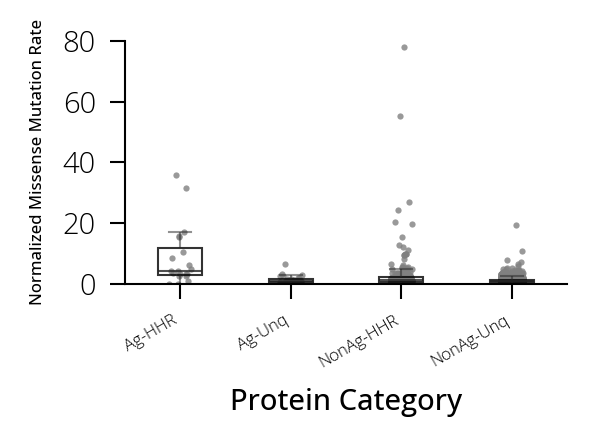

In [107]:
GWMutR_fig, GWMutR_ax = plt.subplots(figsize=(2, 1.5))

in_GeneInfo_DF = Genes_GCandMutFreqStats_DF
X_Order = ['Antigen-HHR', 'Antigen-Unq',  'NonReactive-HHR', 'NonReactive-Unq',  ]

# 2) Strip
sns.stripplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF, color = "grey",
    zorder=0, s=1.5, alpha=0.8,
    ax = GWMutR_ax,
)

# 3) Box
sns.boxplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF,
    width=0.4, showcaps=True, fliersize=0,
    linewidth=0.5,
    boxprops={'facecolor':'none','edgecolor':'black','alpha':0.8},
    whiskerprops={'linewidth':0.5,'alpha':0.5},
    capprops={'linewidth':0.5,'alpha':0.5},
    medianprops={'linewidth':0.5,'alpha':0.8},
    ax = GWMutR_ax,
)

GWMutR_ax.set_ylim(0, 80)
GWMutR_ax.set_xlabel("Protein Category")
GWMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)


# Replace long x-axis labels with shorter ones
short_labels = [ 'Ag-HHR', 'Ag-Unq', 'NonAg-HHR', 'NonAg-Unq',]
GWMutR_ax.set_xticks(range(len(X_Order)))
GWMutR_ax.set_xticks(ticks=range(len(X_Order)), labels=short_labels, fontsize=4, rotation=30, ha='right')

sns.despine()

plt.show()

#### Show plot 

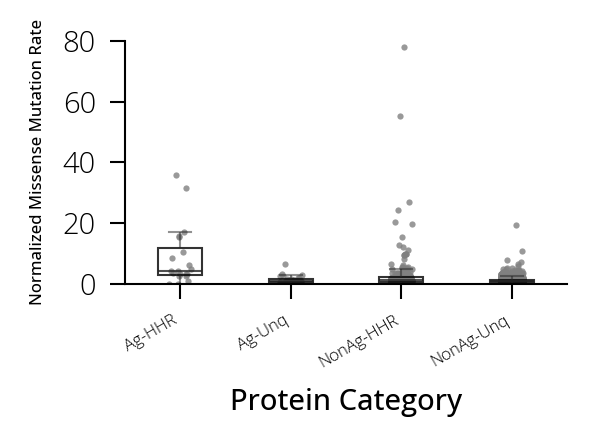

In [108]:

GWMutR_fig

## Statistical Comparison of mutational burden (Genome-wide, 4 categories)


#### Look at distribution stats for each group (`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [109]:
MutationBurdenPerGene_GroupStats_DF = Genes_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe().reset_index()

In [110]:
MutationBurdenPerGene_GroupStats_DF

,AntigenLVL2_And_HHR_Comb,count,mean,std,min,25%,50%,75%,max
0,Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
1,Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
2,NonReactive-HHR,204.0,3.005899,7.481313,0.0,0.598638,1.332993,2.317748,78.102190
3,NonReactive-Unq,3584.0,0.889619,0.813826,0.0,0.385914,0.763359,1.231527,19.251337


# Part 3: Focused mutational burden analysis of `HHR vs Non-HHR antigens`

## A) Compare OVERALL mutation burden between HHR and non-HHR antigens

The median mutational burden of HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA. <br>
The median mutational burden of Non-HHR antigens is 1 missense mutations (IQR: 0-2) per 100 AA. <br>
The mutational burden of HHR antigens is significantly higher than non-HHR antigens. <br>


In [111]:
Antigen_GCandMutFreqStats_DF.groupby("HasHmRegion")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
HasHmRegion,,,,,,,,
False,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
True,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802


In [112]:
Antigen_NonHHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False")["RelFreq_NS_Muts"]
Antigen_HHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True")["RelFreq_NS_Muts"]


In [113]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(Antigen_NonHHR_RelFreq, Antigen_HHR_RelFreq)
# Output the result
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}") 

Wilcoxon rank-sum test statistic: -4.367156268334564
P-value: 1.2587467092606682e-05


In [114]:
### The median mutational burden on HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA .
### This is significantly higher than the mutational burden on non-HHR antigens, with a median of 1 missense mutations (IQR: 0-2) per 100 AA


In [115]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut != Has_mGCE_WiNSMut")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
10,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.5,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,18.0,4.137931,0.0,False,False,False,True,True,True,135,0.103448


In [116]:
Antigen_GCandMutFreqStats_DF.query("Total_NS_Muts_BymGCE != Total_NS_Muts_BypGCE").shape

(4, 38)

In [117]:
Antigen_GCandMutFreqStats_DF.head(1)

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.25,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594


In [118]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 38)

In [119]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 38)

## B) Plot normalized mutation rate of HHR vs non-HHR antigens

#### Code to create plot

In [120]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


Seed: 134


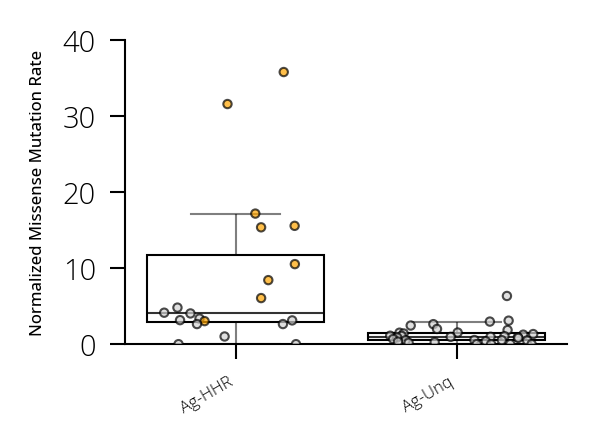

In [121]:
# Create figure and axis
AMutR_fig, AMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 134
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
               order = X_Order, hue = "Has_mGCE_WiNSMut", palette = Has_GC_EpiMut_Pallete,
               jitter = 0.35,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.7, size = 2,
               edgecolor="black", linewidth=0.5, ax = AMutR_ax,
               legend=False, )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = AMutR_ax,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
AMutR_ax.set_ylim(0, 40)
AMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)
AMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-HHR', 'Ag-Unq']
AMutR_ax.set_xticks(range(len(X_Order)))
AMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=30, ha='right')

sns.despine(ax=AMutR_ax)

plt.tight_layout()

plt.show()



#### Show plot 

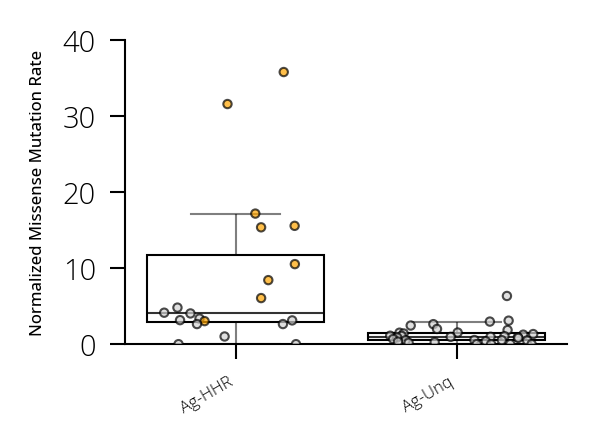

In [122]:

AMutR_fig

### What are the top 10 antigens with the highest OVERALL mutational burden?

In [123]:
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "N_Pos", "Total", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",   ]
# "Length", "H37rv_GeneID",
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",  "Total_NS_Muts_BypGCE",  ]

i_TarCols_V2 = [ "Symbol", "Length", "HasHmRegion", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", ]

Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,PPE60,1182,True,35.786802,6.091371,141.0,24.0
1,esxL,285,True,31.578947,28.421053,30.0,27.0
2,esxP,297,True,17.171717,2.020202,17.0,2.0
3,PPE18,1176,True,15.561224,11.224490,61.0,44.0
4,PPE19,1191,True,15.365239,2.267003,61.0,9.0
5,esxO,285,True,10.526316,3.157895,10.0,3.0
6,esxN,285,True,8.421053,1.052632,8.0,1.0
7,Rv0010c,426,False,6.338028,1.408451,9.0,2.0
8,esxK,297,True,6.060606,3.030303,6.0,3.0
9,Rv3115,1248,True,4.807692,0.240385,20.0,1.0


In [124]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


In [125]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(20)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


### Create table of top 5 HHR and Non-HHR antigens (Ranked by mut-burden in each group)

In [126]:
i_TarCols_V3 = ["HasHmRegion", "Symbol", "Length", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "pGCE_Ovrlap", "mGCE_Ovrlap",]

Top5_HHR_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)

Top5_UNQ_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)


Top5HHR_Vs_Top5Unq_Antigens_Stats_DF = pd.concat([Top5_HHR_Antigen_GCandMutFreqStats_DF, Top5_UNQ_Antigen_GCandMutFreqStats_DF],
                                                 axis =0 )
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF.shape

(10, 9)

In [127]:
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
0,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
1,False,esxH,291,3.092784,3.092784,3.0,3.0,0,0
2,False,esxB,303,2.970297,2.970297,3.0,3.0,0,0
3,False,Rv2660c,228,2.631579,1.315789,2.0,1.0,0,0
4,False,rimJ,612,2.450980,0.490196,5.0,1.0,0,0


### Create table of top 10 antigens (Ranked by mut-burden)

In [128]:
Top10MutBurden_Antigen_Stats_DF = Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V3].reset_index(drop=True)
Top10MutBurden_Antigen_Stats_DF.shape

(10, 9)

In [129]:
Top10MutBurden_Antigen_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
5,True,esxO,285,10.526316,3.157895,10.0,3.0,5,5
6,True,esxN,285,8.421053,1.052632,8.0,1.0,3,3
7,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
8,True,esxK,297,6.060606,3.030303,6.0,3.0,5,3
9,True,Rv3115,1248,4.807692,0.240385,20.0,1.0,0,0


# Part 3: Analysis of GC events mutating MHC-II antigens & epitopes

## Basic questions to ask of GC events mutating epitopes/antigens

In [130]:
mGCE_DF.shape

(213, 50)

In [131]:
pGCE_DF.shape

(324, 50)

In [132]:
#mGCE_DF.columns

In [133]:
#mGCE_DF["N_EpiMutated_By_GCE"].value_counts()

In [134]:
#pGCE_DF["N_EpiMutated_By_GCE"].value_counts()

### 1) How many pGC events cause any AA change? (183/324, 86%)

In [135]:
pGCE_DF.shape

(324, 50)

In [136]:
pGCE_WiNSMut_DF = pGCE_DF.query("N_NS_Mut > 0")
pGCE_WiNSMut_DF.shape

(280, 50)

In [137]:
pGCE_WiNSMut_DF.shape[0] / pGCE_DF.shape[0]

0.8641975308641975

### 2) How many pGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (42/324, 13%)

In [138]:
pGCE_InAntigen_DF = pGCE_DF.query("(Overlap_WiAntigenLVL2Gene == True) ")
pGCE_InAntigen_DF.shape

(48, 50)

In [139]:
44/324


0.13580246913580246

In [140]:
pGCE_WiNSMut_InAntigen_DF = pGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
pGCE_WiNSMut_InAntigen_DF.shape

(42, 50)

In [141]:
pGCE_DF.shape

(324, 50)

In [142]:
42/324

0.12962962962962962

In [143]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

In [144]:
# How many unique HHRs? 7
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP
# PPE46
# esxM, esxN

# How many unique proteins? 10 (PPE18, PPE19, PPE60, esxK, esxL, esxO, esxP, esxM, esxN, PPE46)

### 3) How many pGC events mutate (AA change) an epitope (In L2 Antigen)? (25/324, 10%)

In [145]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF = pGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [146]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(25, 50)

In [147]:
pGCE_DF.shape

(324, 50)

In [148]:
25/324

0.07716049382716049

In [149]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
esxL                 5
PPE60                5
esxK,esxL            3
PPE18,esxK,esxL      1
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

# Part 4: Create PPE18 summary DF of epitope coverage and mutation frequency across the entire protein sequence

In [150]:

# Function to compute 0-based genomic position for the first nucleotide of each codon (in coding direction)
def codon_to_pos0(start0, end0, codon_idx_1based, strand_sign):
    k = int(codon_idx_1based)
    if strand_sign == "+":
        # first nt of codon k
        return start0 + (k - 1) * 3
    else:
        # first nt (in coding direction) of codon k on minus strand
        return (end0 - 1) - (k - 1) * 3

### Create first DF w/ all PPE18 Codon Positions

In [151]:
# --- 1) Get PPE18 metadata (coordinates & length) ---
ppe18_Row_DF = Antigen_GCandMutFreqStats_DF.query("Symbol == 'PPE18'").copy()

if ppe18_Row_DF.empty:
    raise ValueError("Couldn't find PPE18 in the antigen stats table.")
    
ppe18_row = ppe18_Row_DF.iloc[0]

chrom = ppe18_row["Chrom"]
PPE18_start = int(ppe18_row["Start"])
PPE18_end   = int(ppe18_row["End"])
PPE18_strand = ppe18_row["Strand"]
length_DNA = int(ppe18_row["Length"])
length_aa = int(391) #int(length_DNA / 3) #ppe18_AA_length

In [152]:
PPE18_RvPerCodon_NSMutFreq_DF = RvPerCodon_NSMutFreq_DF.query("Symbol == 'PPE18'")
PPE18_RvPerCodon_NSMutFreq_DF.shape

(39, 4)

In [153]:
PPE18_RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
839,PPE18,30.0,4,1339435


## Create DF of PPE18 Epitope And Mutation Frequency Stats per Codon

In [154]:
ppe18_AA_length = 392

# Build coverage DataFrame
PPE18_StatsPerPos_DF = pd.DataFrame({
    "Symbol": "PPE18",
    "Codon": range(1, ppe18_AA_length + 1),
})

PPE18_StatsPerPos_DF["RvCoord_Start_0idx"] = PPE18_StatsPerPos_DF["Codon"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))
PPE18_StatsPerPos_DF["RvCoord_Start_1idx"] = PPE18_StatsPerPos_DF["RvCoord_Start_0idx"] + 1

PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF.merge(Rv_EpitopeCov_NonZero_DF[["start", "Cov_PosEpitopes", "Cov_AssayedPeptides"]], 
                                                      left_on = "RvCoord_Start_0idx", 
                                                      right_on = "start",
                                                      how = "left")


PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF.merge(PPE18_RvPerCodon_NSMutFreq_DF[["Codon", "Mutation_Count"]], on = "Codon", how = "left")

PPE18_StatsPerPos_DF["Cov_PosEpitopes"]     = PPE18_StatsPerPos_DF["Cov_PosEpitopes"].fillna(0)
PPE18_StatsPerPos_DF["Cov_AssayedPeptides"] = PPE18_StatsPerPos_DF["Cov_AssayedPeptides"].fillna(0)


PPE18_StatsPerPos_DF["Mutation_Count"] = PPE18_StatsPerPos_DF["Mutation_Count"].fillna(0)
PPE18_StatsPerPos_DF["NS_MutEvent_Freq"] = PPE18_StatsPerPos_DF["Mutation_Count"]


PPE18_StatsPerPos_DF = PPE18_StatsPerPos_DF[["Symbol", "Codon", "Cov_PosEpitopes", "Cov_AssayedPeptides", "NS_MutEvent_Freq",
                                             "RvCoord_Start_0idx", "RvCoord_Start_1idx"]]

PPE18_StatsPerPos_DF["AssayedPos_EpitopeMapping"] = PPE18_StatsPerPos_DF["Cov_AssayedPeptides"] > 0

PPE18_StatsPerPos_DF["OvrlapWiEpitope"] = PPE18_StatsPerPos_DF["Cov_PosEpitopes"] > 0

PPE18_StatsPerPos_DF["OvrlapWiEpitope_int"] = (PPE18_StatsPerPos_DF["Cov_PosEpitopes"] > 0).astype(int)


PPE18_StatsPerPos_DF.shape

(392, 10)

In [155]:
PPE18_StatsPerPos_DF.to_csv("PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv", sep ="\t", index=False)
!wc -l PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv

393 PPE18.PerAAPos.DetectedEpitopesVsMutFreq.V1.tsv


In [156]:
PPE18_StatsPerPos_DF.shape

(392, 10)

In [157]:
PPE18_StatsPerPos_DF.head()

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1
1,PPE18,2,1.0,1.0,0.0,1339351,1339352,True,True,1
2,PPE18,3,1.0,1.0,0.0,1339354,1339355,True,True,1
3,PPE18,4,1.0,1.0,0.0,1339357,1339358,True,True,1
4,PPE18,5,1.0,1.0,0.0,1339360,1339361,True,True,1


In [158]:
PPE18_StatsPerPos_DF["AssayedPos_EpitopeMapping"].value_counts()

AssayedPos_EpitopeMapping
True     391
False      1
Name: count, dtype: int64

In [159]:
PPE18_StatsPerPos_DF["OvrlapWiEpitope"].value_counts()

OvrlapWiEpitope
True     235
False    157
Name: count, dtype: int64

In [160]:
PPE18_StatsPerPos_DF.groupby("OvrlapWiEpitope")["NS_MutEvent_Freq"].describe()

,count,mean,std,min,25%,50%,75%,max
OvrlapWiEpitope,,,,,,,,
False,157.0,0.108280,0.432340,0.0,0.0,0.0,0.0,3.0
True,235.0,0.187234,0.576468,0.0,0.0,0.0,0.0,4.0


In [161]:
PPE18_StatsPerPos_DF.groupby("OvrlapWiEpitope")["NS_MutEvent_Freq"].sum()

OvrlapWiEpitope
False    17.0
True     44.0
Name: NS_MutEvent_Freq, dtype: float64

## Do Poisson Regression GLM stat test - Validated Mapped Epitopes

In [162]:
# Clean analysis pipeline starting from PPE18 TSV with validated epitope information
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm

In [163]:
# Poisson GLM: mut_cnt ~ is_epitope
X = sm.add_constant(PPE18_StatsPerPos_DF["OvrlapWiEpitope_int"])
y = PPE18_StatsPerPos_DF["NS_MutEvent_Freq"]


pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()
dispersion = pois.deviance / pois.df_resid if pois.df_resid > 0 else np.nan
beta = pois.params["OvrlapWiEpitope_int"]
ci = pois.conf_int().loc["OvrlapWiEpitope_int"].values
rr = float(np.exp(beta))
rr_ci = (float(np.exp(ci[0])), float(np.exp(ci[1])))
rr_p = float(pois.pvalues["OvrlapWiEpitope_int"])


PoisGLM_EpiBinary_Results =  { "Poisson_RateRatio": rr,
    "Poisson_RR_CI_low": rr_ci[0],
    "Poisson_RR_CI_high": rr_ci[1],
    "Poisson_p": rr_p,
    "Poisson_dispersion": dispersion,
    "Poisson_AIC": pois.aic }

print(PoisGLM_EpiBinary_Results)

{'Poisson_RateRatio': 1.7291614518147735, 'Poisson_RR_CI_low': 0.9880002647737267, 'Poisson_RR_CI_high': 3.0263142967142325, 'Poisson_p': 0.055150369925243165, 'Poisson_dispersion': 0.7434024887638779, 'Poisson_AIC': 384.1464323144329}


In [164]:
PoisGLM_EpiBinary_Results

{'Poisson_RateRatio': 1.7291614518147735,
 'Poisson_RR_CI_low': 0.9880002647737267,
 'Poisson_RR_CI_high': 3.0263142967142325,
 'Poisson_p': 0.055150369925243165,
 'Poisson_dispersion': 0.7434024887638779,
 'Poisson_AIC': 384.1464323144329}

In [165]:
# Build predictor matrix: add constant + continuous epitope coverage
X = sm.add_constant(PPE18_StatsPerPos_DF["Cov_PosEpitopes"])
y = PPE18_StatsPerPos_DF["NS_MutEvent_Freq"]

# Fit Poisson GLM
pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Extract results
dispersion = pois.deviance / pois.df_resid if pois.df_resid > 0 else np.nan
beta = pois.params["Cov_PosEpitopes"]
ci = pois.conf_int().loc["Cov_PosEpitopes"].values
rr = float(np.exp(beta))  # multiplicative effect per *one additional overlapping epitope*
rr_ci = (float(np.exp(ci[0])), float(np.exp(ci[1])))
rr_p = float(pois.pvalues["Cov_PosEpitopes"])

PoisGLM_EpiCount_Results = {
    "Poisson_RateRatio_perEpitope": rr,
    "95% CI low": rr_ci[0],
    "95% CI high": rr_ci[1],
    "p-value": rr_p,
    "dispersion": dispersion,
    "AIC": pois.aic
}

print(PoisGLM_EpiCount_Results)

{'Poisson_RateRatio_perEpitope': 1.2349982167285662, '95% CI low': 0.9747148179207605, '95% CI high': 1.5647865070691187, 'p-value': 0.08048432872101026, 'dispersion': 0.7458631976313054, 'AIC': 385.10610877272967}


In [166]:
PoisGLM_EpiCount_Results

{'Poisson_RateRatio_perEpitope': 1.2349982167285662,
 '95% CI low': 0.9747148179207605,
 '95% CI high': 1.5647865070691187,
 'p-value': 0.08048432872101026,
 'dispersion': 0.7458631976313054,
 'AIC': 385.10610877272967}

In [167]:
PoisGLM_EpiBinary_Results

{'Poisson_RateRatio': 1.7291614518147735,
 'Poisson_RR_CI_low': 0.9880002647737267,
 'Poisson_RR_CI_high': 3.0263142967142325,
 'Poisson_p': 0.055150369925243165,
 'Poisson_dispersion': 0.7434024887638779,
 'Poisson_AIC': 384.1464323144329}

### Let's plot the distribution of mutations per codon between epitope and non-epitope regions of PPE18

In [168]:
PPE18_StatsPerPos_DF.head(2)

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1
1,PPE18,2,1.0,1.0,0.0,1339351,1339352,True,True,1


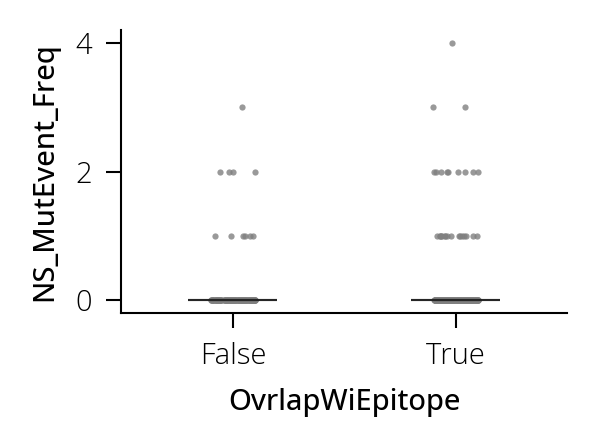

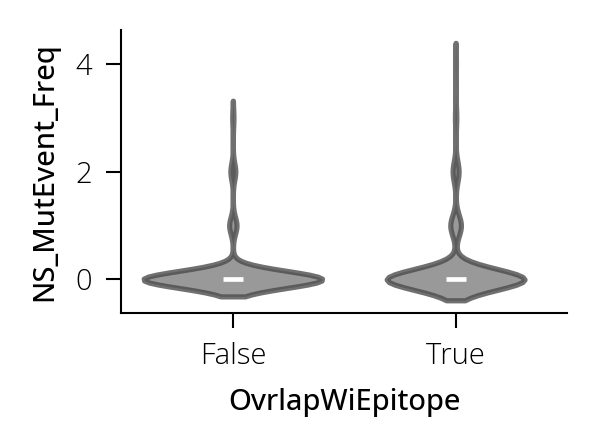

In [169]:
PPE18_fig, PPE18_ax = plt.subplots(figsize=(2, 1.5))

# 2) Strip
sns.stripplot(
    x="OvrlapWiEpitope", y="NS_MutEvent_Freq",
    #order=X_Order,
    data = PPE18_StatsPerPos_DF,
    color = "grey",
    zorder=0, s=1.5, alpha=0.8,
    ax = PPE18_ax,
)

# 3) Box
sns.boxplot(
    x="OvrlapWiEpitope", y="NS_MutEvent_Freq",
    #order=X_Order,
    data=PPE18_StatsPerPos_DF,
    width=0.4, showcaps=True, fliersize=0,
    linewidth=0.5,
    boxprops={'facecolor':'none','edgecolor':'black','alpha':0.8},
    whiskerprops={'linewidth':0.5,'alpha':0.5},
    capprops={'linewidth':0.5,'alpha':0.5},
    medianprops={'linewidth':0.5,'alpha':0.8},
    ax = PPE18_ax,
)

sns.despine()
plt.show()

PPE18_fig, PPE18_ax = plt.subplots(figsize=(2, 1.5))


# 2) Strip
sns.violinplot(
    x="OvrlapWiEpitope", y="NS_MutEvent_Freq",
    #order=X_Order,
    data = PPE18_StatsPerPos_DF,
    color = "grey",
    zorder=0, alpha=0.8,
    ax = PPE18_ax,
)

sns.despine()
plt.show()

## Load netMHCpanII results for `PPE18`

In [227]:
print(PPE18_start, PPE18_end, PPE18_strand)

1339348 1340524 +


In [228]:
# Load epitope prediction results
PPE18_netMHCII_Pred_DF = pd.read_csv("./netMHCpanII.PPE18.predict_result.csv")

PPE18_netMHCII_Pred_DF["Rv_Start"] = PPE18_netMHCII_Pred_DF["start"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))
PPE18_netMHCII_Pred_DF["Rv_End"]   = PPE18_netMHCII_Pred_DF["end"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))

PPE18_netMHCII_Pred_DF["peptideID"] = "PPE18_" + PPE18_netMHCII_Pred_DF["start"].astype(str) + "-" + PPE18_netMHCII_Pred_DF["end"].astype(str)

PPE18_netMHCII_Pred_DF.shape


(10179, 12)

In [232]:
PPE18_netMHCII_Pred_DF.head()

,allele,seq_num,start,end,length,core_peptide,peptide,score,rank,Rv_Start,Rv_End,peptideID
0,HLA-DQA1*01:02/DQB1*06:02,1,84,98,15,LTAAQVRVA,AELTAAQVRVAAAAY,0.8876,0.01,1339597,1339639,PPE18_84-98
1,HLA-DQA1*01:02/DQB1*06:02,1,81,95,15,LTAAQVRVA,AGQAELTAAQVRVAA,0.8990,0.01,1339588,1339630,PPE18_81-95
2,HLA-DQA1*01:02/DQB1*06:02,1,82,96,15,LTAAQVRVA,GQAELTAAQVRVAAA,0.9304,0.01,1339591,1339633,PPE18_82-96
3,HLA-DQA1*01:02/DQB1*06:02,1,83,97,15,LTAAQVRVA,QAELTAAQVRVAAAA,0.9391,0.01,1339594,1339636,PPE18_83-97
4,HLA-DRB1*09:01,1,265,279,15,FAPAAAAQA,MLKGFAPAAAAQAVQ,0.9016,0.02,1340140,1340182,PPE18_265-279


In [233]:
PPE18_netMHCII_Pred_DF["allele"].nunique()

27

In [234]:
PPE18_netMHCII_Pred_DF[["score", "rank"]].describe()

,score,rank
count,10179.000000,10179.000000
mean,0.051275,50.270417
std,0.114484,28.854996
min,0.000100,0.010000
25%,0.002700,25.000000
50%,0.009600,52.000000
75%,0.039500,75.000000
max,0.955900,100.000000


In [172]:
#PPE18_netMHCII_Pred_DF[["start", "end"] ].describe()

In [173]:
PPE18_netMHCII_StrongBinders_DF =   PPE18_netMHCII_Pred_DF[PPE18_netMHCII_Pred_DF["rank"] < 2.0].copy()
PPE18_netMHCII_StrongBinders_DF.shape

(225, 12)

In [174]:
PredEpiMHCII_coverage_array = [0] * ppe18_AA_length

# Count coverage at all overlapping positions
for _, row in PPE18_netMHCII_StrongBinders_DF.iterrows():
    for pos in range(row["start"], row["end"] + 1):
        if 1 <= pos <= ppe18_AA_length:
            PredEpiMHCII_coverage_array[pos - 1] += 1


In [175]:
np.shape(PredEpiMHCII_coverage_array)

(392,)

In [176]:
PPE18_StatsPerPos_V2_DF = PPE18_StatsPerPos_DF.copy()

PPE18_StatsPerPos_V2_DF["netMHCpanII_PredSB_Alleles"] = PredEpiMHCII_coverage_array


In [177]:
PPE18_StatsPerPos_V2_DF.to_csv("PPE18.PerAAPos.DetectedAndPredictedEpitopesVsMutFreq.V2.tsv", sep ="\t", index=False)
!wc -l PPE18.PerAAPos.DetectedAndPredictedEpitopesVsMutFreq.V2.tsv

393 PPE18.PerAAPos.DetectedAndPredictedEpitopesVsMutFreq.V2.tsv


In [178]:
PPE18_StatsPerPos_V2_DF.head(3)

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int,netMHCpanII_PredSB_Alleles
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1,0
1,PPE18,2,1.0,1.0,0.0,1339351,1339352,True,True,1,0
2,PPE18,3,1.0,1.0,0.0,1339354,1339355,True,True,1,0


In [179]:
PPE18_StatsPerPos_V2_DF["netMHCpanII_PredSB_Alleles"].describe()

count    392.000000
mean       8.609694
std        9.668850
min        0.000000
25%        3.000000
50%        6.000000
75%       10.000000
max       50.000000
Name: netMHCpanII_PredSB_Alleles, dtype: float64

## Do Poisson Regression GLM stat test - `netMHCpanII` Predicted Strong Binder Allele Frequency

In [180]:
# Clean analysis pipeline starting from PPE18 TSV with validated epitope information
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm

In [181]:
# Build predictor matrix: add constant + continuous epitope coverage
X = sm.add_constant(PPE18_StatsPerPos_V2_DF["netMHCpanII_PredSB_Alleles"])
y = PPE18_StatsPerPos_V2_DF["NS_MutEvent_Freq"]

# Fit Poisson GLM
pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Extract results
dispersion = pois.deviance / pois.df_resid if pois.df_resid > 0 else np.nan
beta = pois.params["netMHCpanII_PredSB_Alleles"]
ci = pois.conf_int().loc["netMHCpanII_PredSB_Alleles"].values
rr = float(np.exp(beta))  # multiplicative effect per *one additional overlapping epitope*
rr_ci = (float(np.exp(ci[0])), float(np.exp(ci[1])))
rr_p = float(pois.pvalues["netMHCpanII_PredSB_Alleles"])

PoisGLM_PredEpiCount_Results = {
    "Poisson_RateRatio_perEpitope": rr,
    "95% CI low": rr_ci[0],
    "95% CI high": rr_ci[1],
    "p-value": rr_p,
    "dispersion": dispersion,
    "AIC": pois.aic
}

print(PoisGLM_PredEpiCount_Results)

{'Poisson_RateRatio_perEpitope': 0.9769073153320209, '95% CI low': 0.9452491679868505, '95% CI high': 1.009625752733265, 'p-value': 0.16452388908833582, 'dispersion': 0.7477257469737639, 'AIC': 385.8325030162885}


In [182]:
PoisGLM_PredEpiCount_Results

{'Poisson_RateRatio_perEpitope': 0.9769073153320209,
 '95% CI low': 0.9452491679868505,
 '95% CI high': 1.009625752733265,
 'p-value': 0.16452388908833582,
 'dispersion': 0.7477257469737639,
 'AIC': 385.8325030162885}

# Analysis of Epitope Response Frequency and Mutational Burden

### prepare and process relevant data

In [183]:
Lind16_EpiPosFreq_DF.head()

,Epitope_Seq,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s)
0,AAAQASAAAAAYEAA,0,63,0.0,PPE30
1,AAASAWDGLAEELHA,0,63,0.0,PPE42
2,AAASWDALAAELASA,0,63,0.0,PPE50
3,AAATATATATLLPFE,0,63,0.0,PPE18
4,AADMWGPSSDPAWER,0,63,0.0,fbpB


In [184]:
Lind16_EpiPosFreq_DF["Epitope_Seq"].nunique()

761

In [185]:
#L16_AllPep_V2_DF.head()

In [186]:
#L16_AllPep_V2_DF.shape

In [187]:
L16_AllPep_V2_DF = LPM_AllPep_V2_DF.query("Assayed_Lindestam16 == True")
L16_AllPep_V2_DF.shape

(893, 31)

In [188]:
L16_AllPep_V3_DF = pd.merge(L16_AllPep_V2_DF, Lind16_EpiPosFreq_DF,
                            on = "Epitope_Seq", how = "inner" )

L16_AllPep_V3_DF["Epitope_ResponseFreq_LTBI"] = L16_AllPep_V3_DF["Fraction_Positive"]

#L16_AllPep_V3_DF["IsMutByGCE"] = L16_AllPep_V3_DF["IsMutByGCE"].astype(str)

L16_AllPep_V3_DF.shape

(893, 36)

In [189]:
L16_AllPep_V3_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI
0,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,12,63,0.190476,esxB,0.190476
1,UnqPeptide_48,SGSEAYQGVQQKWDA,15,Rv3875,esxA,45,60,NC_000962.3,4352743,4352788,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_48-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,2,63,0.031746,esxA,0.031746
2,UnqPeptide_51,RHVKPTGSAVVGLSM,15,Rv3804c,fbpA,155,170,NC_000962.3,4266148,4266193,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_51-fbpA,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,fbpA,0.000000
3,UnqPeptide_68,GKPANPDVLVVGNGG,15,Rv2608,PPE42,250,265,NC_000962.3,2935795,2935840,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_68-PPE42,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,PPE42,0.000000
4,UnqPeptide_84,APQINFFYYLGEPIV,15,Rv1172c,PE12,231,246,NC_000962.3,1301943,1301988,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_84-PE12,0,False,False,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,PE12,0.000000


In [190]:
L16_AllPep_InHHR_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == True")
L16_AllPep_InHHR_V3_DF.shape

(309, 36)

In [191]:
L16_AllPep_UNQR_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == False")
L16_AllPep_UNQR_V3_DF.shape

(584, 36)

In [192]:
L16_PosEpi_V3_DF = L16_AllPep_V3_DF.query("PosEpitope_Lindestam16 == True")
L16_PosEpi_V3_DF.shape

(318, 36)

In [193]:
L16_PosEpi_InHHR_V3_DF = L16_PosEpi_V3_DF.query("HasHmRegion == True")
L16_PosEpi_InHHR_V3_DF.shape

(158, 36)

In [194]:
L16_PosEpi_UNQR_V3_DF = L16_PosEpi_V3_DF.query("HasHmRegion == False")
L16_PosEpi_UNQR_V3_DF.shape

(160, 36)

In [195]:
L16_AllPep_L2Antigens_V3_DF = L16_AllPep_V3_DF.query("Antigen_LVL2 == True")
L16_AllPep_L2Antigens_V3_DF.shape 

(765, 36)

In [196]:
L16_AllPep_L2Antigens_V3_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.AllAntigens.tsv", sep="\t", index=False)


In [197]:
L16_AllPep_InHHR_L2Antigen_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == True & Antigen_LVL2 == True")
L16_AllPep_InHHR_L2Antigen_V3_DF.shape

(306, 36)

In [198]:
L16_AllPep_InHHR_L2Antigen_V3_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.HHRAntigens.tsv", sep="\t", index=False)


In [199]:
L16_AllPep_InHHR_V3_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.AllAntigens.tsv", sep="\t", index=False)


In [200]:
L16_AllPep_V3_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI
0,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,12,63,0.190476,esxB,0.190476
1,UnqPeptide_48,SGSEAYQGVQQKWDA,15,Rv3875,esxA,45,60,NC_000962.3,4352743,4352788,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_48-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,2,63,0.031746,esxA,0.031746
2,UnqPeptide_51,RHVKPTGSAVVGLSM,15,Rv3804c,fbpA,155,170,NC_000962.3,4266148,4266193,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_51-fbpA,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,fbpA,0.000000
3,UnqPeptide_68,GKPANPDVLVVGNGG,15,Rv2608,PPE42,250,265,NC_000962.3,2935795,2935840,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_68-PPE42,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,PPE42,0.000000
4,UnqPeptide_84,APQINFFYYLGEPIV,15,Rv1172c,PE12,231,246,NC_000962.3,1301943,1301988,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_84-PE12,0,False,False,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,PE12,0.000000


In [201]:
L16_AllPep_V3_DF["Epitope_Seq"].nunique()

693

In [202]:
L16_PosEpi_V3_DF["Epitope_Seq"].nunique()

207

In [203]:
L16_PosEpi_InHHR_V3_DF["Epitope_Seq"].nunique()

58

In [204]:
L16_PosEpi_UNQR_V3_DF["Epitope_Seq"].nunique()

150

### Dataset of all assayed PEPTIDES (N = 887) - epitope response rate vs mutation frequency

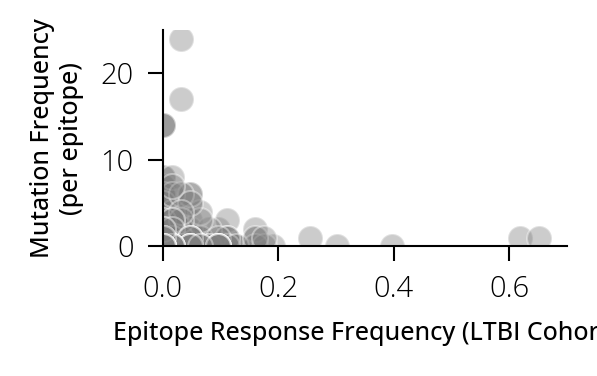

Spearman correlation: 0.06730269818462277
p-value: 0.0443596146561596


In [205]:
plt.figure(figsize=(2,1.3))

IN_DF = L16_AllPep_V3_DF

sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency\n(per epitope)", fontsize=6)
plt.xlim(0, 0.7)
plt.ylim(0, 25)
sns.despine()
plt.tight_layout()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'],
                          IN_DF['N_NSMut_Total'])

print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')


### Dataset of all epitopes (N = 316) - epitope response rate vs mutation frequency

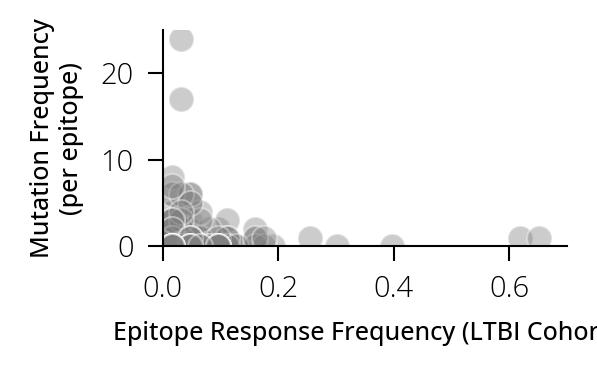

Spearman correlation: 0.07748669898472665
p-value: 0.16807438207548173


In [206]:
plt.figure(figsize=(2,1.3))

IN_DF = L16_PosEpi_V3_DF

sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency\n(per epitope)", fontsize=6)
plt.xlim(0, 0.7)
plt.ylim(0, 25)
sns.despine()
plt.tight_layout()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'],
                          IN_DF['N_NSMut_Total'])

print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')



### Dataset of HHR epitopes (N = 156) - epitope response rate vs mutation frequency

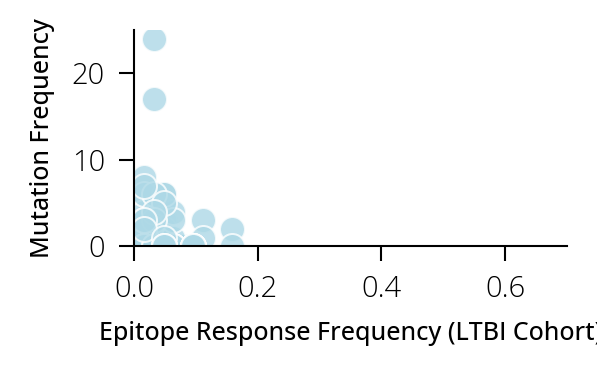

Spearman correlation: 0.028673753874730996
p-value: 0.7206163565983177


In [208]:
plt.figure(figsize=(2,1.3))

IN_DF = L16_PosEpi_InHHR_V3_DF

sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "lightblue",
                data = IN_DF, alpha = 0.8)

plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency", fontsize=6)
plt.xlim(0, 0.7)
plt.ylim(0, 25)
sns.despine()
plt.tight_layout()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'],
                          IN_DF['N_NSMut_Total'])

print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')



### Dataset of non-HHR (UNQ) epitopes (N = 160) - epitope response rate vs mutation frequency

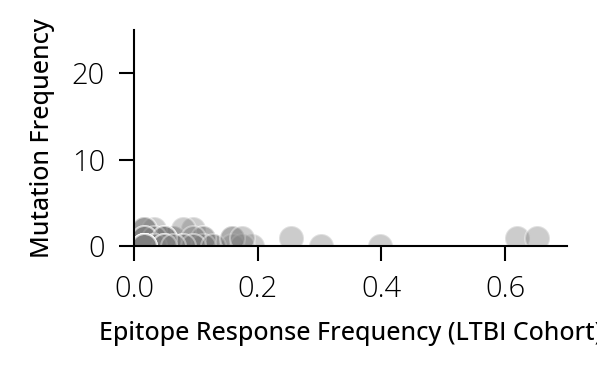

Spearman correlation: 0.15265085014285082
p-value: 0.05397124338779212


count    160.000000
mean       0.287500
std        0.530664
min        0.000000
25%        0.000000
50%        0.000000
75%        0.250000
max        2.000000
Name: N_NSMut_Total, dtype: float64

In [209]:
plt.figure(figsize=(2,1.3))

IN_DF = L16_PosEpi_UNQR_V3_DF

sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)

plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency", fontsize=6)
plt.xlim(0, 0.7)
plt.ylim(0, 25)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'],
                          IN_DF['N_NSMut_Total'])

print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')

IN_DF['N_NSMut_Total'].describe()

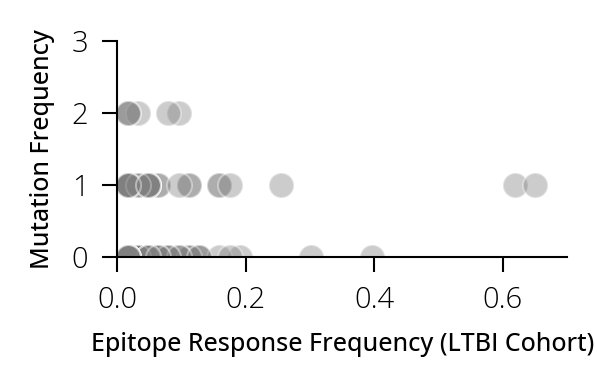

Spearman correlation: 0.15265085014285082
p-value: 0.05397124338779212


count    160.000000
mean       0.287500
std        0.530664
min        0.000000
25%        0.000000
50%        0.000000
75%        0.250000
max        2.000000
Name: N_NSMut_Total, dtype: float64

In [210]:
plt.figure(figsize=(2,1.3))

IN_DF = L16_PosEpi_UNQR_V3_DF

sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)

plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency", fontsize=6)
plt.xlim(0, 0.7)
plt.ylim(0, 3)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'],
                          IN_DF['N_NSMut_Total'])

print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')

IN_DF['N_NSMut_Total'].describe()

## Explore mutational burden per epitope in top HHR-antigens

In [211]:
#L16_PosEpi_V3_DF.head(1)

In [212]:
L16_PosEpi_WiRF_PPE18_DF = L16_PosEpi_V3_DF.query("Symbol == 'PPE18' ").sort_values("N_NSMut_Total", ascending=False)
L16_PosEpi_WiRF_PPE18_DF.shape

(25, 36)

In [213]:
# L16_PosEpi_WiRF_PPE19_DF = L16_PosEpi_V3_DF.query("Symbol == 'PPE19' ").sort_values("N_NSMut_Total", ascending=False)
# L16_PosEpi_WiRF_PPE19_DF.shape

In [214]:
# L16_PosEpi_WiRF_PPE60_DF = L16_PosEpi_V3_DF.query("Symbol == 'PPE60' ").sort_values("N_NSMut_Total", ascending=False)
# L16_PosEpi_WiRF_PPE60_DF.shape

In [215]:
# L16_PosEpi_WiRF_esxL_DF = L16_PosEpi_V3_DF.query("Symbol == 'esxL' ").sort_values("N_NSMut_Total", ascending=False)
# L16_PosEpi_WiRF_esxL_DF.shape

In [216]:
L16_AllPep_WiRF_PPE18_DF = L16_AllPep_V3_DF.query("Symbol == 'PPE18' ").sort_values("N_NSMut_Total", ascending=False)

L16_AllPep_WiRF_PPE18_DF = bf.count_overlaps(L16_AllPep_WiRF_PPE18_DF,
                                             L16_PosEpi_WiRF_PPE18_DF,
                                             cols1 = ["Chrom", "Rv_Start", "Rv_End"],
                                             cols2 = ["Chrom", "Rv_Start", "Rv_End"]).rename(columns={"count": "N_Ovrlap_PosEpi"})

L16_AllPep_WiRF_PPE18_DF["Ovrlap_PosEpi"] = L16_AllPep_WiRF_PPE18_DF["N_Ovrlap_PosEpi"] > 0

L16_AllPep_WiRF_PPE18_DF["Reactivity_WiPosEpiOvrlap"] = L16_AllPep_WiRF_PPE18_DF["Reactivity"]+"-"+L16_AllPep_WiRF_PPE18_DF["Ovrlap_PosEpi"].astype(str)  

L16_AllPep_WiRF_PPE18_DF.shape

(78, 39)

In [217]:
L16_AllPep_WiRF_PPE18_DF["Ovrlap_PosEpi"].value_counts()

Ovrlap_PosEpi
True     55
False    23
Name: count, dtype: Int64

#### Output TSVs of peptide response frequency and mutationa frequency for individual antigens

In [218]:
L16_AllPep_WiRF_PPE18_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.PPE18.tsv", sep="\t", index=False)
#L16_AllPep_WiRF_PPE19_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.PPE19.tsv", sep="\t", index=False)
#L16_AllPep_WiRF_PPE60_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.PPE60.tsv", sep="\t", index=False)
#L16_AllPep_WiRF_esxL_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.esxL.tsv", sep="\t", index=False)


In [219]:
L16_AllPep_WiRF_PPE18_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
0,UnqPeptide_8271,VNEAEYGEMWAQDAA,15,Rv1196,PPE18,135,150,NC_000962.3,1339753,1339798,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8271-PPE18,1,True,True,8,8,True,8,True,1,Event_094,1,Event_094,Negative,0,63,0.000000,"PPE18, PPE19",0.000000,3,True,Negative-True
1,UnqPeptide_8012,EAPEMTSAGGLLEQA,15,Rv1196,PPE18,170,185,NC_000962.3,1339858,1339903,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8012-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True
2,UnqPeptide_16998,LLPFEEAPEMTSAGG,15,Rv1196,PPE18,165,180,NC_000962.3,1339843,1339888,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_16998-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Positive,1,63,0.015873,PPE18,0.015873,1,True,Positive-True
3,UnqPeptide_1093,QGTTPSSKLGGLWKT,15,Rv1196,PPE18,215,230,NC_000962.3,1339993,1340038,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_1093-PPE18,1,True,True,7,7,True,7,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,1,True,Negative-True
4,UnqPeptide_9330,QALQQLAQPTQGTTP,15,Rv1196,PPE18,205,220,NC_000962.3,1339963,1340008,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_9330-PPE18,1,True,True,6,6,True,6,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True


In [221]:
L16_AllPep_WiRF_PPE18_DF[["Num_Positive", "N_NSMut_Total"]].describe()

,Num_Positive,N_NSMut_Total
count,78.000000,78.000000
mean,0.692308,2.371795
std,1.302422,2.251170
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,2.000000
75%,1.000000,4.000000
max,7.000000,8.000000


In [201]:
L16_AllPep_WiRF_PPE18_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
0,UnqPeptide_8271,VNEAEYGEMWAQDAA,15,Rv1196,PPE18,135,150,NC_000962.3,1339753,1339798,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8271-PPE18,1,True,True,8,8,True,8,True,1,Event_094,1,Event_094,Negative,0,63,0.0,"PPE18, PPE19",0.0,3,True,Negative-True


In [202]:
EpiInfo_TarCols = ["EpitopeSymbol_ID", "Epitope_ID", "Epitope_Seq", "RvID", "Symbol",
                          "AA_Start", "AA_End", "PosEpitope_Lindestam16",
                          "HasHmRegion", "N_NSMut_Total", "Reactivity", "Num_Positive",
                          "Num_Assayed", "Epitope_ResponseFreq_LTBI"]

L16_PosEpi_WiRF_PPE18_DF[EpiInfo_TarCols].head(10)

,EpitopeSymbol_ID,Epitope_ID,Epitope_Seq,RvID,Symbol,AA_Start,AA_End,PosEpitope_Lindestam16,HasHmRegion,N_NSMut_Total,Reactivity,Num_Positive,Num_Assayed,Epitope_ResponseFreq_LTBI
796,UnqPeptide_16998-PPE18,UnqPeptide_16998,LLPFEEAPEMTSAGG,Rv1196,PPE18,165,180,True,True,7,Positive,1,63,0.015873
706,UnqPeptide_15452-PPE18,UnqPeptide_15452,LAQPTQGTTPSSKLG,Rv1196,PPE18,210,225,True,True,6,Positive,1,63,0.015873
732,UnqPeptide_15834-PPE18,UnqPeptide_15834,IAENRAELMILIATN,Rv1196,PPE18,110,125,True,True,6,Positive,3,63,0.047619
430,UnqPeptide_8677-PPE18,UnqPeptide_8677,AELMILIATNLLGQN,Rv1196,PPE18,115,130,True,True,6,Positive,1,63,0.015873
767,UnqPeptide_16444-PPE18,UnqPeptide_16444,YGEMWAQDAAAMFGY,Rv1196,PPE18,140,155,True,True,6,Positive,2,63,0.031746
353,UnqPeptide_7207-PPE18,UnqPeptide_7207,TPAIAVNEAEYGEMW,Rv1196,PPE18,130,145,True,True,6,Positive,3,63,0.047619
65,UnqPeptide_1141-PPE18,UnqPeptide_1141,GSASLVAAAQMWDSV,Rv1196,PPE18,20,35,True,True,5,Positive,3,63,0.047619
783,UnqPeptide_16789-PPE18,UnqPeptide_16789,VAAAQMWDSVASDLF,Rv1196,PPE18,25,40,True,True,5,Positive,3,63,0.047619
94,UnqPeptide_1812-PPE18,UnqPeptide_1812,LLGQNTPAIAVNEAE,Rv1196,PPE18,125,140,True,True,4,Positive,2,63,0.031746
807,UnqPeptide_17231-PPE18,UnqPeptide_17231,VPPPVIAENRAELMI,Rv1196,PPE18,105,120,True,True,4,Positive,2,63,0.031746


In [203]:
L16_AllPep_WiRF_PPE18_DF.sort_values("Epitope_ResponseFreq_LTBI", ascending=False).head(20)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
24,UnqPeptide_5494,LIATNLLGQNTPAIA,15,Rv1196,PPE18,120,135,NC_000962.3,1339708,1339753,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_5494-PPE18,1,True,True,3,3,True,3,True,1,Event_094,1,Event_094,Positive,7,63,0.111111,"PPE18, PPE19",0.111111,5,True,Positive-True
70,UnqPeptide_11128,ALPPEINSARMYAGP,15,Rv1196,PPE18,5,20,NC_000962.3,1339363,1339408,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_11128-PPE18,1,True,True,0,0,False,0,False,0,.,0,.,Positive,5,63,0.079365,"PPE18, PPE19, PPE60",0.079365,3,True,Positive-True
47,UnqPeptide_4240,SPYVAWMSVTAGQAE,15,Rv1196,PPE18,70,85,NC_000962.3,1339558,1339603,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_4240-PPE18,1,True,True,1,0,False,0,False,0,.,0,.,Positive,3,63,0.047619,"PPE18, PPE19",0.047619,3,True,Positive-True
13,UnqPeptide_16789,VAAAQMWDSVASDLF,15,Rv1196,PPE18,25,40,NC_000962.3,1339423,1339468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16789-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,3,63,0.047619,PPE18,0.047619,2,True,Positive-True
75,UnqPeptide_14292,AANQLMNNVPQALQQ,15,Rv1196,PPE18,195,210,NC_000962.3,1339933,1339978,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_14292-PPE18,1,True,True,0,0,False,0,False,0,.,0,.,Positive,3,63,0.047619,"PPE18, PPE19, PPE60",0.047619,2,True,Positive-True
6,UnqPeptide_15834,IAENRAELMILIATN,15,Rv1196,PPE18,110,125,NC_000962.3,1339678,1339723,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_15834-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,3,63,0.047619,"PPE18, PPE19",0.047619,4,True,Positive-True
8,UnqPeptide_7207,TPAIAVNEAEYGEMW,15,Rv1196,PPE18,130,145,NC_000962.3,1339738,1339783,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_7207-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,3,63,0.047619,"PPE18, PPE19",0.047619,4,True,Positive-True
42,UnqPeptide_5681,MVAAASPYVAWMSVT,15,Rv1196,PPE18,65,80,NC_000962.3,1339543,1339588,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_5681-PPE18,1,True,True,1,0,False,0,False,0,.,0,.,Positive,3,63,0.047619,"PPE18, PPE19",0.047619,3,True,Positive-True
11,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive,3,63,0.047619,PPE18,0.047619,3,True,Positive-True
29,UnqPeptide_16960,AAVEEASDTAAANQL,15,Rv1196,PPE18,185,200,NC_000962.3,1339903,1339948,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_16960-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive,2,63,0.031746,PPE18,0.031746,3,True,Positive-True


In [204]:
L16_PosEpi_WiRF_PPE18_DF[EpiInfo_TarCols].sort_values("Epitope_ResponseFreq_LTBI", ascending=False).head(20)

,EpitopeSymbol_ID,Epitope_ID,Epitope_Seq,RvID,Symbol,AA_Start,AA_End,PosEpitope_Lindestam16,HasHmRegion,N_NSMut_Total,Reactivity,Num_Positive,Num_Assayed,Epitope_ResponseFreq_LTBI
261,UnqPeptide_5494-PPE18,UnqPeptide_5494,LIATNLLGQNTPAIA,Rv1196,PPE18,120,135,True,True,3,Positive,7,63,0.111111
523,UnqPeptide_11128-PPE18,UnqPeptide_11128,ALPPEINSARMYAGP,Rv1196,PPE18,5,20,True,True,0,Positive,5,63,0.079365
783,UnqPeptide_16789-PPE18,UnqPeptide_16789,VAAAQMWDSVASDLF,Rv1196,PPE18,25,40,True,True,5,Positive,3,63,0.047619
65,UnqPeptide_1141-PPE18,UnqPeptide_1141,GSASLVAAAQMWDSV,Rv1196,PPE18,20,35,True,True,5,Positive,3,63,0.047619
664,UnqPeptide_14292-PPE18,UnqPeptide_14292,AANQLMNNVPQALQQ,Rv1196,PPE18,195,210,True,True,0,Positive,3,63,0.047619
268,UnqPeptide_5681-PPE18,UnqPeptide_5681,MVAAASPYVAWMSVT,Rv1196,PPE18,65,80,True,True,1,Positive,3,63,0.047619
196,UnqPeptide_4240-PPE18,UnqPeptide_4240,SPYVAWMSVTAGQAE,Rv1196,PPE18,70,85,True,True,1,Positive,3,63,0.047619
353,UnqPeptide_7207-PPE18,UnqPeptide_7207,TPAIAVNEAEYGEMW,Rv1196,PPE18,130,145,True,True,6,Positive,3,63,0.047619
732,UnqPeptide_15834-PPE18,UnqPeptide_15834,IAENRAELMILIATN,Rv1196,PPE18,110,125,True,True,6,Positive,3,63,0.047619
767,UnqPeptide_16444-PPE18,UnqPeptide_16444,YGEMWAQDAAAMFGY,Rv1196,PPE18,140,155,True,True,6,Positive,2,63,0.031746


In [205]:
L16_PosEpi_WiRF_PPE18_DF[EpiInfo_TarCols]

,EpitopeSymbol_ID,Epitope_ID,Epitope_Seq,RvID,Symbol,AA_Start,AA_End,PosEpitope_Lindestam16,HasHmRegion,N_NSMut_Total,Reactivity,Num_Positive,Num_Assayed,Epitope_ResponseFreq_LTBI
796,UnqPeptide_16998-PPE18,UnqPeptide_16998,LLPFEEAPEMTSAGG,Rv1196,PPE18,165,180,True,True,7,Positive,1,63,0.015873
706,UnqPeptide_15452-PPE18,UnqPeptide_15452,LAQPTQGTTPSSKLG,Rv1196,PPE18,210,225,True,True,6,Positive,1,63,0.015873
732,UnqPeptide_15834-PPE18,UnqPeptide_15834,IAENRAELMILIATN,Rv1196,PPE18,110,125,True,True,6,Positive,3,63,0.047619
430,UnqPeptide_8677-PPE18,UnqPeptide_8677,AELMILIATNLLGQN,Rv1196,PPE18,115,130,True,True,6,Positive,1,63,0.015873
767,UnqPeptide_16444-PPE18,UnqPeptide_16444,YGEMWAQDAAAMFGY,Rv1196,PPE18,140,155,True,True,6,Positive,2,63,0.031746
353,UnqPeptide_7207-PPE18,UnqPeptide_7207,TPAIAVNEAEYGEMW,Rv1196,PPE18,130,145,True,True,6,Positive,3,63,0.047619
65,UnqPeptide_1141-PPE18,UnqPeptide_1141,GSASLVAAAQMWDSV,Rv1196,PPE18,20,35,True,True,5,Positive,3,63,0.047619
783,UnqPeptide_16789-PPE18,UnqPeptide_16789,VAAAQMWDSVASDLF,Rv1196,PPE18,25,40,True,True,5,Positive,3,63,0.047619
94,UnqPeptide_1812-PPE18,UnqPeptide_1812,LLGQNTPAIAVNEAE,Rv1196,PPE18,125,140,True,True,4,Positive,2,63,0.031746
807,UnqPeptide_17231-PPE18,UnqPeptide_17231,VPPPVIAENRAELMI,Rv1196,PPE18,105,120,True,True,4,Positive,2,63,0.031746


In [206]:
L16_AllPep_WiRF_PPE18_DF.shape

(78, 39)

In [207]:
L16_AllPep_WiRF_PPE18_DF["Reactivity"].value_counts()

Reactivity
Negative    51
Positive    27
Name: count, dtype: int64

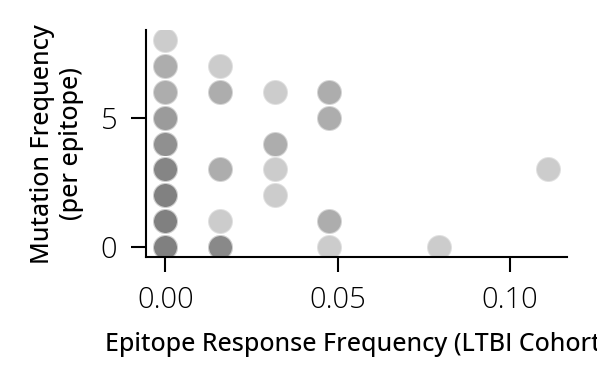

Spearman correlation: 0.14406927256031052
p-value: 0.20824012607532116


In [208]:

IN_DF = L16_AllPep_WiRF_PPE18_DF

plt.figure(figsize=(2,1.3))
sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency\n(per epitope)", fontsize=6)
#plt.xlim(0, 0.7), plt.ylim(0, 25)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'], IN_DF['N_NSMut_Total'])
print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')


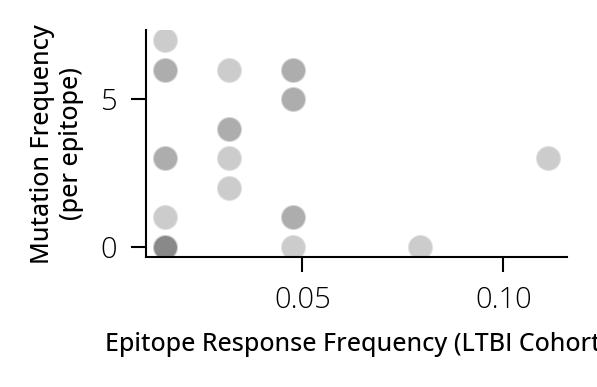

Spearman correlation: 0.1094084196809996
p-value: 0.6026434404037997


In [209]:

IN_DF = L16_PosEpi_WiRF_PPE18_DF

plt.figure(figsize=(2,1.3))
sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency\n(per epitope)", fontsize=6)
#plt.xlim(0, 0.7), plt.ylim(0, 25)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'], IN_DF['N_NSMut_Total'])
print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')


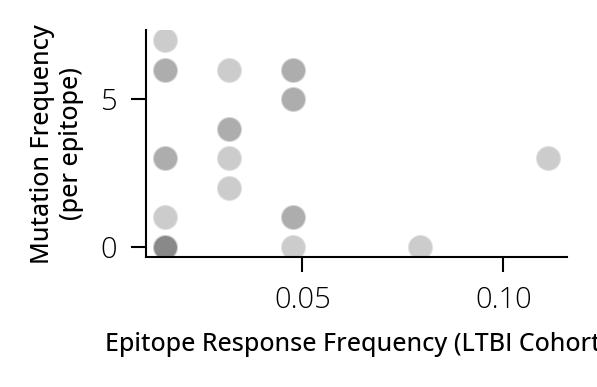

Spearman correlation: 0.1094084196809996
p-value: 0.6026434404037997


In [210]:

IN_DF = L16_PosEpi_WiRF_PPE18_DF

plt.figure(figsize=(2,1.3))
sns.scatterplot(x = "Epitope_ResponseFreq_LTBI", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("Epitope Response Frequency (LTBI Cohort)", fontsize=6)
plt.ylabel("Mutation Frequency\n(per epitope)", fontsize=6)
#plt.xlim(0, 0.7), plt.ylim(0, 25)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'], IN_DF['N_NSMut_Total'])
print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')



In [211]:
L16_AllPep_WiRF_PPE18_DF.head(5)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
0,UnqPeptide_8271,VNEAEYGEMWAQDAA,15,Rv1196,PPE18,135,150,NC_000962.3,1339753,1339798,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8271-PPE18,1,True,True,8,8,True,8,True,1,Event_094,1,Event_094,Negative,0,63,0.000000,"PPE18, PPE19",0.000000,3,True,Negative-True
1,UnqPeptide_8012,EAPEMTSAGGLLEQA,15,Rv1196,PPE18,170,185,NC_000962.3,1339858,1339903,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8012-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True
2,UnqPeptide_16998,LLPFEEAPEMTSAGG,15,Rv1196,PPE18,165,180,NC_000962.3,1339843,1339888,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_16998-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Positive,1,63,0.015873,PPE18,0.015873,1,True,Positive-True
3,UnqPeptide_1093,QGTTPSSKLGGLWKT,15,Rv1196,PPE18,215,230,NC_000962.3,1339993,1340038,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_1093-PPE18,1,True,True,7,7,True,7,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,1,True,Negative-True
4,UnqPeptide_9330,QALQQLAQPTQGTTP,15,Rv1196,PPE18,205,220,NC_000962.3,1339963,1340008,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_9330-PPE18,1,True,True,6,6,True,6,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True


In [212]:
L16_AllPep_WiRF_PPE18_DF.groupby("Num_Positive")["N_NSMut_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
Num_Positive,,,,,,,,
0,53.0,2.132075,2.121662,0.0,0.0,2.0,3.0,8.0
1,11.0,2.363636,2.802596,0.0,0.0,1.0,4.5,7.0
2,5.0,3.800000,1.483240,2.0,3.0,4.0,4.0,6.0
3,7.0,3.428571,2.636737,0.0,1.0,5.0,5.5,6.0
5,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
7,1.0,3.000000,NaN,3.0,3.0,3.0,3.0,3.0


In [213]:
L16_AllPep_WiRF_PPE18_DF.groupby("Num_Positive")["N_mGCEs_WiNS"].describe()

,count,mean,std,min,25%,50%,75%,max
Num_Positive,,,,,,,,
0,53.0,0.547170,0.637484,0.0,0.0,0.0,1.0,3.0
1,11.0,0.545455,0.687552,0.0,0.0,0.0,1.0,2.0
2,5.0,1.200000,0.447214,1.0,1.0,1.0,1.0,2.0
3,7.0,1.142857,1.345185,0.0,0.0,1.0,2.0,3.0
5,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
7,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0


In [214]:
L16_AllPep_WiRF_PPE18_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
0,UnqPeptide_8271,VNEAEYGEMWAQDAA,15,Rv1196,PPE18,135,150,NC_000962.3,1339753,1339798,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8271-PPE18,1,True,True,8,8,True,8,True,1,Event_094,1,Event_094,Negative,0,63,0.000000,"PPE18, PPE19",0.000000,3,True,Negative-True
1,UnqPeptide_8012,EAPEMTSAGGLLEQA,15,Rv1196,PPE18,170,185,NC_000962.3,1339858,1339903,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8012-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True
2,UnqPeptide_16998,LLPFEEAPEMTSAGG,15,Rv1196,PPE18,165,180,NC_000962.3,1339843,1339888,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_16998-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Positive,1,63,0.015873,PPE18,0.015873,1,True,Positive-True
3,UnqPeptide_1093,QGTTPSSKLGGLWKT,15,Rv1196,PPE18,215,230,NC_000962.3,1339993,1340038,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_1093-PPE18,1,True,True,7,7,True,7,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,1,True,Negative-True
4,UnqPeptide_9330,QALQQLAQPTQGTTP,15,Rv1196,PPE18,205,220,NC_000962.3,1339963,1340008,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_9330-PPE18,1,True,True,6,6,True,6,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True


In [215]:
L16_AllPep_WiRF_PPE18_DF["Ovrlap_PosEpi"].value_counts()

Ovrlap_PosEpi
True     55
False    23
Name: count, dtype: Int64

In [216]:
L16_AllPep_WiRF_PPE18_DF.groupby("Reactivity_WiPosEpiOvrlap")["N_NSMut_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
Reactivity_WiPosEpiOvrlap,,,,,,,,
Negative-False,23.0,1.695652,1.520609,0.0,0.5,2.0,2.0,5.0
Negative-True,28.0,2.464286,2.516349,0.0,0.0,1.5,4.0,8.0
Positive-True,27.0,2.851852,2.413164,0.0,0.5,3.0,5.0,7.0


In [226]:
L16_AllPep_WiRF_PPE18_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
0,UnqPeptide_8271,VNEAEYGEMWAQDAA,15,Rv1196,PPE18,135,150,NC_000962.3,1339753,1339798,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8271-PPE18,1,True,True,8,8,True,8,True,1,Event_094,1,Event_094,Negative,0,63,0.000000,"PPE18, PPE19",0.000000,3,True,Negative-True
1,UnqPeptide_8012,EAPEMTSAGGLLEQA,15,Rv1196,PPE18,170,185,NC_000962.3,1339858,1339903,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_8012-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True
2,UnqPeptide_16998,LLPFEEAPEMTSAGG,15,Rv1196,PPE18,165,180,NC_000962.3,1339843,1339888,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_16998-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Positive,1,63,0.015873,PPE18,0.015873,1,True,Positive-True
3,UnqPeptide_1093,QGTTPSSKLGGLWKT,15,Rv1196,PPE18,215,230,NC_000962.3,1339993,1340038,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_1093-PPE18,1,True,True,7,7,True,7,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,1,True,Negative-True
4,UnqPeptide_9330,QALQQLAQPTQGTTP,15,Rv1196,PPE18,205,220,NC_000962.3,1339963,1340008,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_9330-PPE18,1,True,True,6,6,True,6,True,1,Event_097,1,Event_097,Negative,0,63,0.000000,PPE18,0.000000,2,True,Negative-True


In [224]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF = L16_AllPep_WiRF_PPE18_DF.query("Reactivity_WiPosEpiOvrlap != 'Negative-True' ")
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.shape

(50, 39)

In [225]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.to_csv("Lind16.PPE18.NegPeptidesVsPosEpitopes.WithPatientResponseFreq.tsv", sep="\t", index=False)  


In [219]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.groupby("Reactivity_WiPosEpiOvrlap")["N_NSMut_Total"].describe()

,count,mean,std,min,25%,50%,75%,max
Reactivity_WiPosEpiOvrlap,,,,,,,,
Negative-False,23.0,1.695652,1.520609,0.0,0.5,2.0,2.0,5.0
Positive-True,27.0,2.851852,2.413164,0.0,0.5,3.0,5.0,7.0


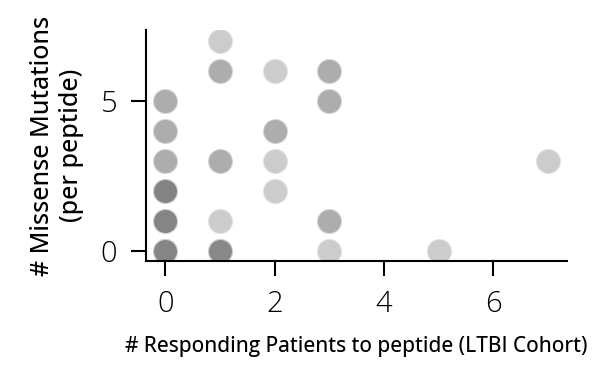

Spearman correlation: 0.23067816306097352
p-value: 0.10702616191773809


In [220]:

IN_DF = L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF

plt.figure(figsize=(2,1.3))
sns.scatterplot(x = "Num_Positive", y = "N_NSMut_Total", color = "grey",
                data = IN_DF, alpha = 0.4)
plt.xlabel("# Responding Patients to peptide (LTBI Cohort)", fontsize=5)
plt.ylabel("# Missense Mutations\n(per peptide)", fontsize=6)
#plt.xlim(0, 0.7), plt.ylim(0, 25)
sns.despine()
plt.show()

corr, p_value = spearmanr(IN_DF['Epitope_ResponseFreq_LTBI'], IN_DF['N_NSMut_Total'])
print(f'Spearman correlation: {corr}')
print(f'p-value: {p_value}')



In [223]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.head(3)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,N_Ovrlap_PosEpi,Ovrlap_PosEpi,Reactivity_WiPosEpiOvrlap
2,UnqPeptide_16998,LLPFEEAPEMTSAGG,15,Rv1196,PPE18,165,180,NC_000962.3,1339843,1339888,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_16998-PPE18,1,True,True,7,7,True,7,True,1,Event_095,1,Event_095,Positive,1,63,0.015873,PPE18,0.015873,1,True,Positive-True
5,UnqPeptide_8677,AELMILIATNLLGQN,15,Rv1196,PPE18,115,130,NC_000962.3,1339693,1339738,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_8677-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,1,63,0.015873,"PPE18, PPE19",0.015873,5,True,Positive-True
6,UnqPeptide_15834,IAENRAELMILIATN,15,Rv1196,PPE18,110,125,NC_000962.3,1339678,1339723,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_15834-PPE18,1,True,True,6,6,True,6,True,1,Event_094,1,Event_094,Positive,3,63,0.047619,"PPE18, PPE19",0.047619,4,True,Positive-True


In [229]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.head(1)[["Epitope_Seq", "AA_Start"]]

,Epitope_Seq,AA_Start
2,LLPFEEAPEMTSAGG,165


In [231]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

In [232]:
L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF.head(1)[["Epitope_Seq", "AA_Start", "AA_End", "N_NSMut_Total", "N_NSMut_mGCE", "Reactivity_WiPosEpiOvrlap"]]

,Epitope_Seq,AA_Start,AA_End,N_NSMut_Total,N_NSMut_mGCE,Reactivity_WiPosEpiOvrlap
2,LLPFEEAPEMTSAGG,165,180,7,7,Positive-True


In [233]:
# Build predictor matrix: add constant + continuous epitope coverage
X = sm.add_constant(L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF["Num_Positive"])
y = L16_AllPep_WiRF_NoNegPepOvrlapWiPosEpi_PPE18_DF["N_NSMut_Total"]


pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()
dispersion = pois.deviance / pois.df_resid if pois.df_resid > 0 else np.nan
beta = pois.params["Num_Positive"]
ci = pois.conf_int().loc["Num_Positive"].values
rr = float(np.exp(beta))
rr_ci = (float(np.exp(ci[0])), float(np.exp(ci[1])))
rr_p = float(pois.pvalues["Num_Positive"])


PoisGLM_EpiResponseFreq_VsMutFreq_Results =  { "Poisson_RateRatio": rr,
    "Poisson_RR_CI_low": rr_ci[0],
    "Poisson_RR_CI_high": rr_ci[1],
    "Poisson_p": rr_p,
    "Poisson_dispersion": dispersion,
    "Poisson_AIC": pois.aic }

print(PoisGLM_EpiResponseFreq_VsMutFreq_Results)

{'Poisson_RateRatio': 1.1136201326556268, 'Poisson_RR_CI_low': 1.0012231883637108, 'Poisson_RR_CI_high': 1.2386347162840885, 'Poisson_p': 0.04742514527473762, 'Poisson_dispersion': 2.21660562469714, 'Poisson_AIC': 216.33773946880186}


In [234]:
PoisGLM_EpiResponseFreq_VsMutFreq_Results

{'Poisson_RateRatio': 1.1136201326556268,
 'Poisson_RR_CI_low': 1.0012231883637108,
 'Poisson_RR_CI_high': 1.2386347162840885,
 'Poisson_p': 0.04742514527473762,
 'Poisson_dispersion': 2.21660562469714,
 'Poisson_AIC': 216.33773946880186}

# Generate PPE18 gene-level visualizations of netMHCpanII predictions

In [238]:
PPE18_StatsPerPos_V2_DF.head(1)

,Symbol,Codon,Cov_PosEpitopes,Cov_AssayedPeptides,NS_MutEvent_Freq,RvCoord_Start_0idx,RvCoord_Start_1idx,AssayedPos_EpitopeMapping,OvrlapWiEpitope,OvrlapWiEpitope_int,netMHCpanII_PredSB_Alleles
0,PPE18,1,1.0,1.0,0.0,1339348,1339349,True,True,1,0


#### Gen simple NetMHCpan Strong Binder Cov for PPE18

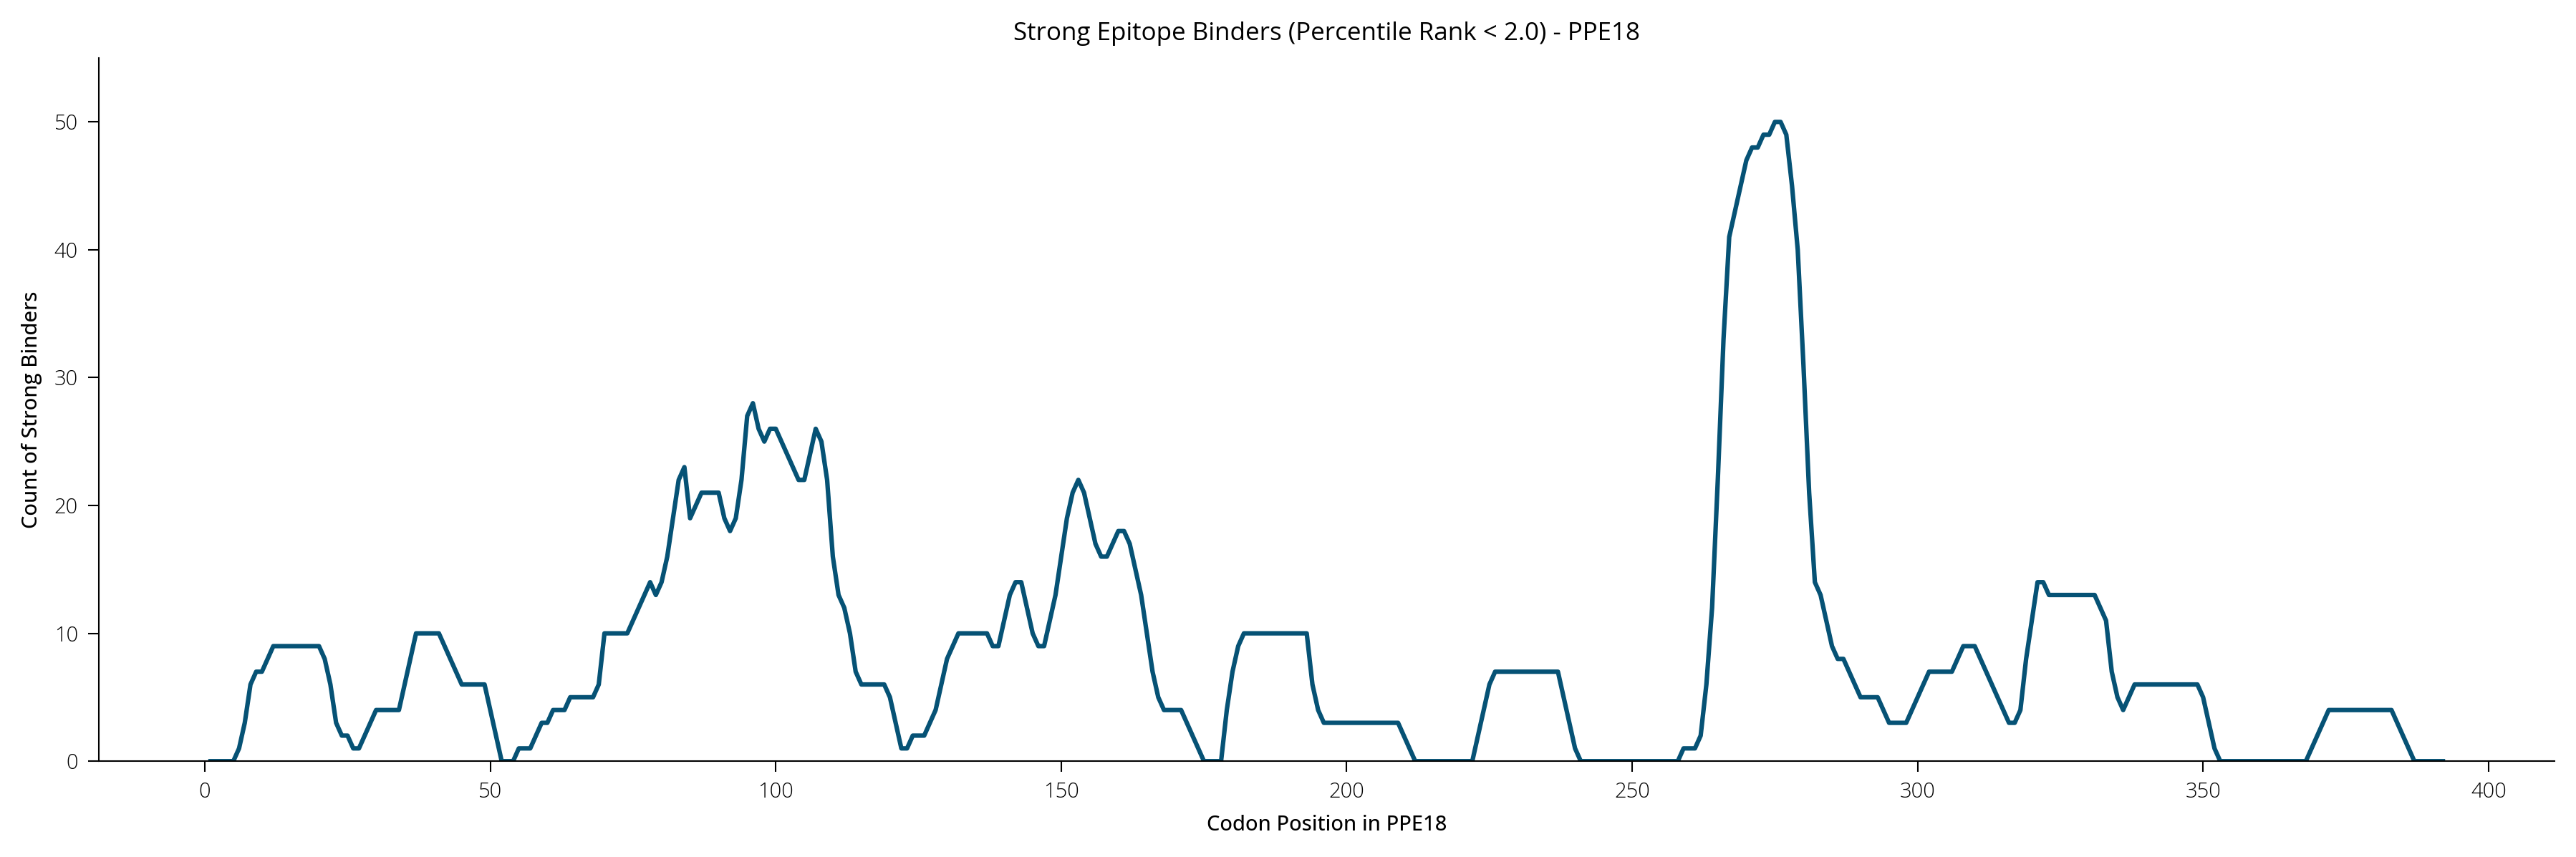

In [239]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=PPE18_StatsPerPos_V2_DF,
             x="Codon", y="netMHCpanII_PredSB_Alleles",
             linewidth=1.5)

plt.ylim(0, 55)

plt.title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
plt.xlabel("Codon Position in PPE18")
plt.ylabel("Count of Strong Binders")
plt.tight_layout()
sns.despine()
plt.show()

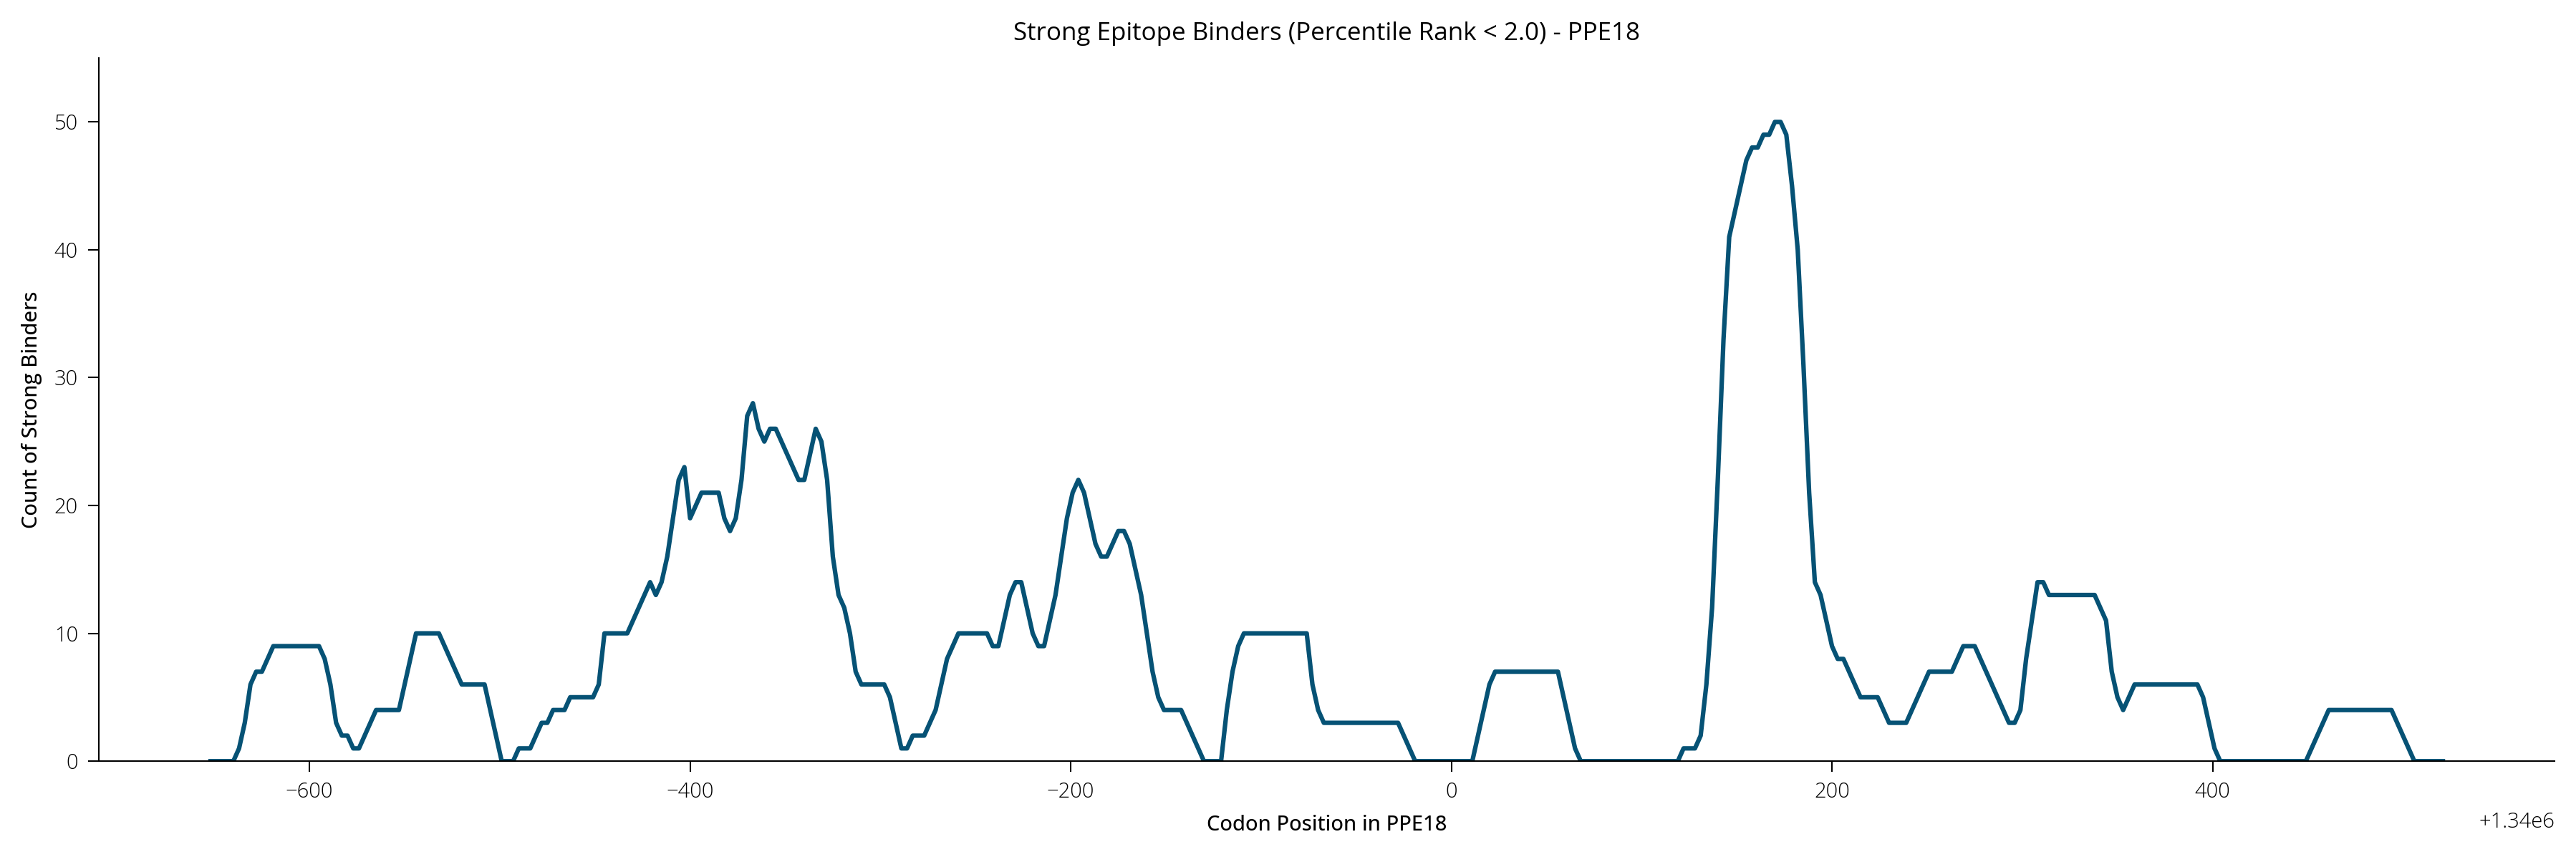

In [241]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=PPE18_StatsPerPos_V2_DF,
             x = "RvCoord_Start_0idx",
             y = "netMHCpanII_PredSB_Alleles",
             linewidth=1.5)
plt.ylim(0, 55)
plt.title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
plt.xlabel("Codon Position in PPE18")
plt.ylabel("Count of Strong Binders")
plt.tight_layout()
sns.despine()
plt.show()

# Explore predicted strong binder HLA Alleles to PPE18 (`H37Rv`) epitopes

In [243]:
PPE18_netMHCII_StrongBinders_DF.head(4)

,allele,seq_num,start,end,length,core_peptide,peptide,score,rank,Rv_Start,Rv_End,peptideID
0,HLA-DQA1*01:02/DQB1*06:02,1,84,98,15,LTAAQVRVA,AELTAAQVRVAAAAY,0.8876,0.01,1339597,1339639,PPE18_84-98
1,HLA-DQA1*01:02/DQB1*06:02,1,81,95,15,LTAAQVRVA,AGQAELTAAQVRVAA,0.8990,0.01,1339588,1339630,PPE18_81-95
2,HLA-DQA1*01:02/DQB1*06:02,1,82,96,15,LTAAQVRVA,GQAELTAAQVRVAAA,0.9304,0.01,1339591,1339633,PPE18_82-96
3,HLA-DQA1*01:02/DQB1*06:02,1,83,97,15,LTAAQVRVA,QAELTAAQVRVAAAA,0.9391,0.01,1339594,1339636,PPE18_83-97


In [244]:
len("AELTAAQVRVAAAAY")

15

In [148]:
len(netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures)

100

### Create DNA-Features-Viewer objects for predicted `StrongBinder` epitopes within `PPE18`

In [247]:
def generate_netMHCpanII_Epitope_GraphicFeatures(i_Epitopes_DF):
    L_GFeats = []
    
    for i, row in i_Epitopes_DF.iterrows():
        
        Rv_Start = row["Rv_Start"]
        Rv_End = row["Rv_End"]
        i_epitope_seq = row["peptide"]
        i_epitope_ID = row["peptideID"]

        Epitope_Feat = GraphicFeature(start = Rv_Start , end = Rv_End ,
                                      peptideID = i_epitope_ID,
                                      color = "darkred",
                                      linecolor = "black",
                                      thickness = 2,
                                      linewidth = 0.5,)
        L_GFeats.append(Epitope_Feat)

    return L_GFeats


In [248]:
netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_StrongBinders_DF.head(100))


#netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_StrongBinders_DF.query("Rv_Start == 1339597"))

#netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_Pred_DF)
                                                 
netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                              features = netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures)


In [249]:
len(netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures)

100

## Try to plot w/ PPE18 and Predicted Epitopes, etc

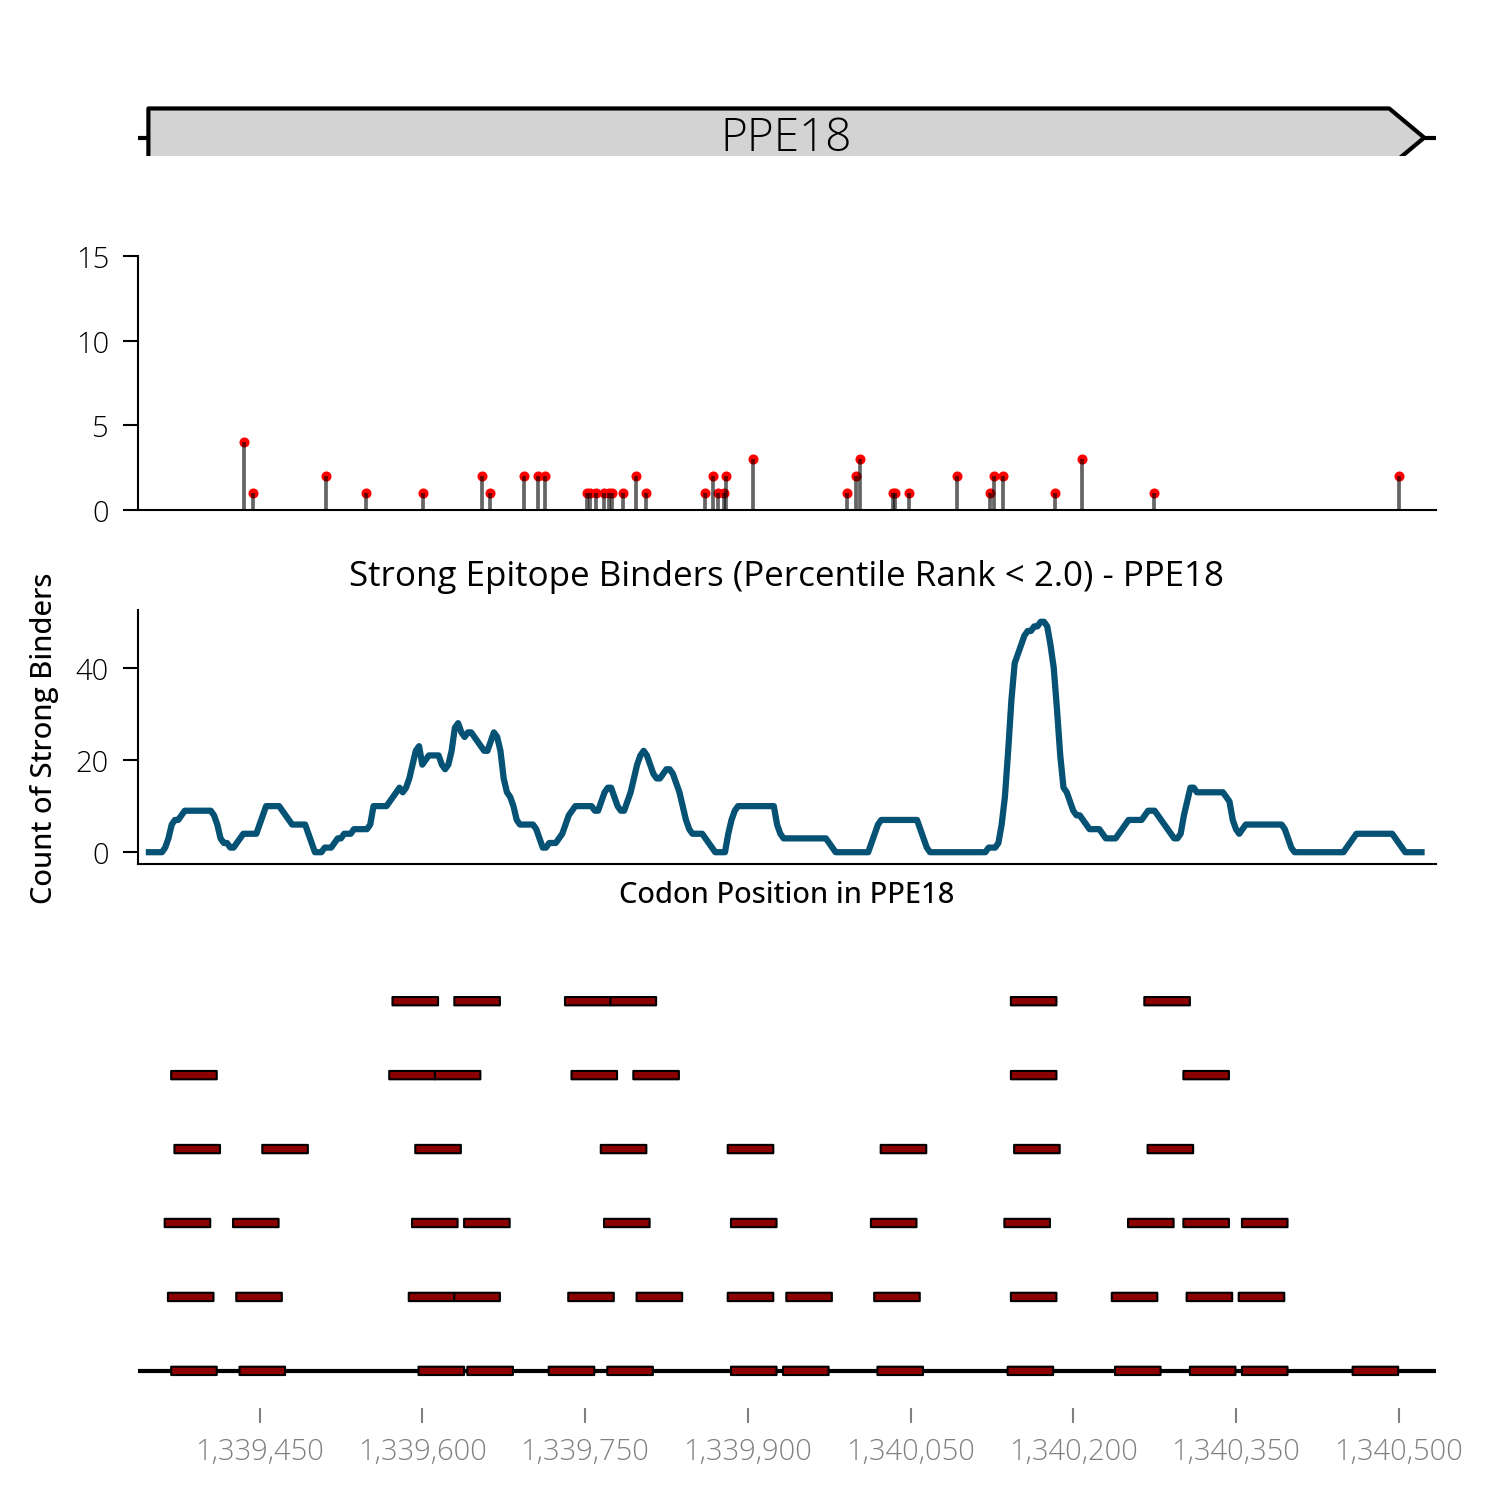

In [252]:

in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF

    

i_Symbol = "PPE18"
    
i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10



fig, axs = plt.subplots(4, 1, figsize=(5, 5),
                        gridspec_kw={'height_ratios': [2, 4, 4, 7]})         


# # C) Create graphic records for viz
Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

PPE18_StrongBindPredEpitopes_Records_cropped = netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))


#PosEpitopes_Records_cropped = LPM_PosEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))

### Define subplot location for different plots ###

# 1st subplot is of genome annotated features
H37Rv_Anno_ax = axs[0]

# 2nd subplot is for summary of epitope coverage per position
EpiSumm_ax = axs[2]

# 2nd subplot is for summary of epitope coverage per position

MF_ax = axs[1]

AllAssayedPeptides_ax = axs[3]


####### Gene Annotation Records #######
Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                            ax = H37Rv_Anno_ax)

H37Rv_Anno_ax.set_xlim(Viz_Start, Viz_End)

H37Rv_Anno_ax.set_xticks([])

#######################################


############## Mut Freq Plot ##############
MF_ax.vlines(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              ymin = 0, 
              ymax = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color = "black", linewidth=0.9, alpha = 0.6)

MF_ax.scatter(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              y = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color="red", s = 2, alpha = 1)

MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
MF_ax.ticklabel_format(style='plain', axis='x')
MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
MF_ax.set_xlim(Viz_Start, Viz_End)
MF_ax.set_ylim(0, 15)
MF_ax.set_xticks([])

sns.despine(ax=MF_ax)



###########################################

################# Predicted Epitope (StrongBinder) Coverage #################


sns.lineplot(data = PPE18_StatsPerPos_V2_DF,
             x = "RvCoord_Start_0idx",
             y = "netMHCpanII_PredSB_Alleles",
             linewidth=1.5,
             ax = EpiSumm_ax)

EpiSumm_ax.set_title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
EpiSumm_ax.set_xlabel("Codon Position in PPE18")
EpiSumm_ax.set_ylabel("Count of Strong Binders")
EpiSumm_ax.set_xlim(Viz_Start, Viz_End)

EpiSumm_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
EpiSumm_ax.ticklabel_format(style='plain', axis='x')
EpiSumm_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#MF_ax.set_ylim(0, 15)
EpiSumm_ax.set_xticks([])

sns.despine(ax=EpiSumm_ax)

#EpiSumm_ax.set_ylim(0, 1)


#####################################################


####### Predicted Epitopes - netMHCpanII #######
PredictedEpitopes_ax = axs[3]

PPE18_StrongBindPredEpitopes_Records_cropped.plot(strand_in_label_threshold=5,
                                 ax = PredictedEpitopes_ax)

PredictedEpitopes_ax.set_xlim(Viz_Start, Viz_End)
PredictedEpitopes_ax.set_ylim(-0.5, 5.5)

#AllAssayedPeptides_ax.set_xticks([])

######################################################

#plt.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")

plt.show()

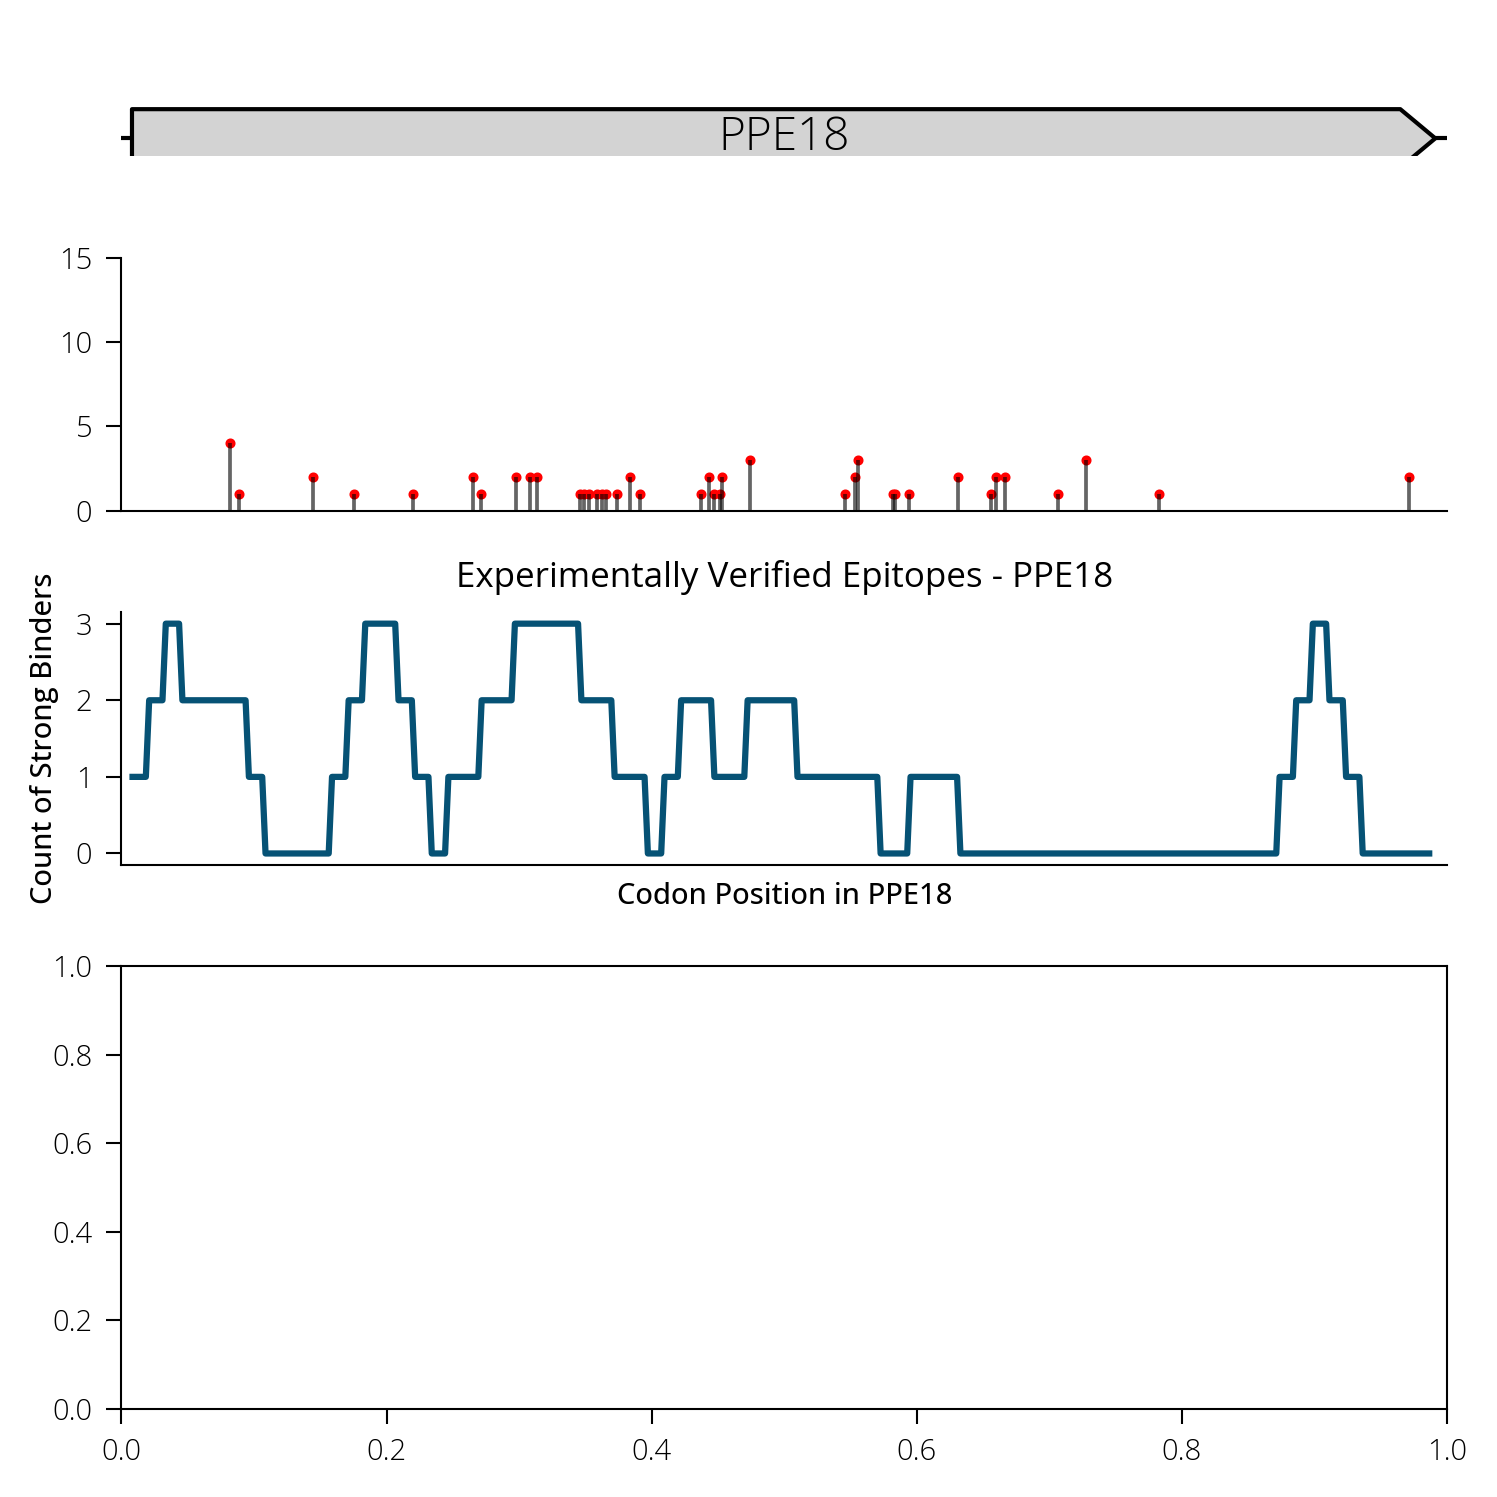

In [185]:

in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF

    

i_Symbol = "PPE18"
    
i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10



fig, axs = plt.subplots(4, 1, figsize=(5, 5),
                        gridspec_kw={'height_ratios': [2, 4, 4, 7]})         


# # C) Create graphic records for viz
Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

PPE18_StrongBindPredEpitopes_Records_cropped = netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))


#PosEpitopes_Records_cropped = LPM_PosEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))

### Define subplot location for different plots ###

# 1st subplot is of genome annotated features
H37Rv_Anno_ax = axs[0]

# 2nd subplot is for summary of epitope coverage per position
EpiSumm_ax = axs[2]

# 2nd subplot is for summary of epitope coverage per position

MF_ax = axs[1]

AllAssayedPeptides_ax = axs[3]


####### Gene Annotation Records #######
Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                            ax = H37Rv_Anno_ax)

H37Rv_Anno_ax.set_xlim(Viz_Start, Viz_End)

H37Rv_Anno_ax.set_xticks([])

#######################################


############## Mut Freq Plot ##############
MF_ax.vlines(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              ymin = 0, 
              ymax = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color = "black", linewidth=0.9, alpha = 0.6)

MF_ax.scatter(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              y = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color="red", s = 2, alpha = 1)

MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
MF_ax.ticklabel_format(style='plain', axis='x')
MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
MF_ax.set_xlim(Viz_Start, Viz_End)
MF_ax.set_ylim(0, 15)
MF_ax.set_xticks([])

sns.despine(ax=MF_ax)



###########################################

################# Predicted Epitope (StrongBinder) Coverage #################


sns.lineplot(data = PPE18_netMHC_SB_Cov_DF,
             x = "Rv_Pos0",
             y = "Cov_PosEpitopes",
             linewidth=1.5,
             ax = EpiSumm_ax)

EpiSumm_ax.set_title("Experimentally Verified Epitopes - PPE18")
EpiSumm_ax.set_xlabel("Codon Position in PPE18")
EpiSumm_ax.set_ylabel("Count of Strong Binders")
EpiSumm_ax.set_xlim(Viz_Start, Viz_End)

EpiSumm_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
EpiSumm_ax.ticklabel_format(style='plain', axis='x')
EpiSumm_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#MF_ax.set_ylim(0, 15)
EpiSumm_ax.set_xticks([])

sns.despine(ax=EpiSumm_ax)

#EpiSumm_ax.set_ylim(0, 1)


#####################################################


####### Predicted Epitopes - netMHCpanII #######
# PredictedEpitopes_ax = axs[3]

# PPE18_StrongBindPredEpitopes_Records_cropped.plot(strand_in_label_threshold=5,
#                                  ax = PredictedEpitopes_ax)

# PredictedEpitopes_ax.set_xlim(Viz_Start, Viz_End)
# PredictedEpitopes_ax.set_ylim(-0.5, 5.5)

#AllAssayedPeptides_ax.set_xticks([])

######################################################

#plt.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")

plt.show()

In [ ]:
STOP!!!

# Extras

# Part Z: Regression of positivity fraction w/

## Organize all ASSAYED peptides in PPE18 (from experimental data)

In [170]:
LPM_AllPep_V2_InL2Antigen_DF = LPM_AllPep_V2_DF.query("Antigen_LVL2 == True")
LPM_AllPep_V2_InL2Antigen_DF.shape

(924, 31)

In [171]:

LPM_AllPep_V2_InHHRAntigen_DF = LPM_AllPep_V2_InL2Antigen_DF.query("HasHmRegion == True")
LPM_AllPep_V2_InHHRAntigen_DF.shape


(345, 31)

In [172]:
LPM_AllPep_V2_InPPE18_DF = LPM_AllPep_V2_InHHRAntigen_DF.query("Symbol == 'PPE18'")  
LPM_AllPep_V2_InPPE18_DF.shape

(82, 31)

In [175]:
LPM_PosEpi_V2_InPPE18_DF = LPM_AllPep_V2_InPPE18_DF.query(" PosEpitope_Any == True")
LPM_PosEpi_V2_InPPE18_DF.shape

(27, 31)

In [176]:
LPM_PosEpi_V2_InPPE18_DF.head(4)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
963,UnqPeptide_959,RSPISNMVSMANNHM,15,Rv1196,PPE18,234,249,NC_000962.3,1340050,1340095,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_959-PPE18,1,True,True,2,1,True,1,True,1,Event_096,1,Event_096,Positive
1002,UnqPeptide_998,LLEQAAAVEEASDTA,15,Rv1196,PPE18,180,195,NC_000962.3,1339888,1339933,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_998-PPE18,1,True,True,3,2,True,2,True,2,"Event_096,Event_095",2,"Event_096,Event_095",Positive
1146,UnqPeptide_1141,GSASLVAAAQMWDSV,15,Rv1196,PPE18,20,35,NC_000962.3,1339408,1339453,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_1141-PPE18,1,True,True,5,3,True,3,True,3,"Event_092,Event_093,Event_091",3,"Event_092,Event_093,Event_091",Positive
1817,UnqPeptide_1812,LLGQNTPAIAVNEAE,15,Rv1196,PPE18,125,140,NC_000962.3,1339723,1339768,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_1812-PPE18,1,True,True,4,4,True,4,True,1,Event_094,1,Event_094,Positive


## Load netMHCpanII results for `PPE18`

In [126]:
# --- 1) Get PPE18 metadata (coordinates & length) ---
ppe18_row = Antigen_GCandMutFreqStats_DF.query("Symbol == 'PPE18'").copy()
if ppe18_row.empty:
    raise ValueError("Couldn't find PPE18 in the antigen stats table.")
ppe18_row = ppe18_row.iloc[0]

chrom = ppe18_row["Chrom"]
PPE18_start = int(ppe18_row["Start"])
PPE18_end   = int(ppe18_row["End"])
PPE18_strand = ppe18_row["Strand"]
length_DNA = int(ppe18_row["Length"])
length_aa = int(391) #int(length_DNA / 3) #ppe18_AA_length

In [127]:
print(PPE18_start, PPE18_end, PPE18_strand)

1339348 1340524 +


In [128]:
# Load epitope prediction results
PPE18_netMHCII_Pred_DF = pd.read_csv("./netMHCpanII.PPE18.predict_result.csv")

PPE18_netMHCII_Pred_DF["Rv_Start"] = PPE18_netMHCII_Pred_DF["start"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))
PPE18_netMHCII_Pred_DF["Rv_End"] = PPE18_netMHCII_Pred_DF["end"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))

PPE18_netMHCII_Pred_DF["peptideID"] = "PPE18_" + PPE18_netMHCII_Pred_DF["start"].astype(str) + "-" + PPE18_netMHCII_Pred_DF["end"].astype(str)

PPE18_netMHCII_Pred_DF.shape


(10179, 12)

In [129]:
#PPE18_netMHCII_Pred_DF[["start", "end"] ].describe()

In [130]:
PPE18_netMHCII_StrongBinders_DF =   PPE18_netMHCII_Pred_DF[PPE18_netMHCII_Pred_DF["rank"] < 2.0].copy()
PPE18_netMHCII_StrongBinders_DF.shape

(225, 12)

In [131]:
PPE18_netMHCII_StrongBinders_DF.head()

,allele,seq_num,start,end,length,core_peptide,peptide,score,rank,Rv_Start,Rv_End,peptideID
0,HLA-DQA1*01:02/DQB1*06:02,1,84,98,15,LTAAQVRVA,AELTAAQVRVAAAAY,0.8876,0.01,1339597,1339639,PPE18_84-98
1,HLA-DQA1*01:02/DQB1*06:02,1,81,95,15,LTAAQVRVA,AGQAELTAAQVRVAA,0.8990,0.01,1339588,1339630,PPE18_81-95
2,HLA-DQA1*01:02/DQB1*06:02,1,82,96,15,LTAAQVRVA,GQAELTAAQVRVAAA,0.9304,0.01,1339591,1339633,PPE18_82-96
3,HLA-DQA1*01:02/DQB1*06:02,1,83,97,15,LTAAQVRVA,QAELTAAQVRVAAAA,0.9391,0.01,1339594,1339636,PPE18_83-97
4,HLA-DRB1*09:01,1,265,279,15,FAPAAAAQA,MLKGFAPAAAAQAVQ,0.9016,0.02,1340140,1340182,PPE18_265-279


In [132]:
PPE18_netMHCII_StrongBinders_DF.sort_values("start").head(5)

,allele,seq_num,start,end,length,core_peptide,peptide,score,rank,Rv_Start,Rv_End,peptideID
47,HLA-DQA1*01:02/DQB1*06:02,1,6,20,15,INSARMYAG,ALPPEINSARMYAGP,0.6880,0.41,1339363,1339405,PPE18_6-20
166,HLA-DQA1*04:01/DQB1*04:02,1,7,21,15,INSARMYAG,LPPEINSARMYAGPG,0.2090,1.50,1339366,1339408,PPE18_7-21
16,HLA-DQA1*01:02/DQB1*06:02,1,7,21,15,INSARMYAG,LPPEINSARMYAGPG,0.7938,0.10,1339366,1339408,PPE18_7-21
14,HLA-DQA1*01:02/DQB1*06:02,1,8,22,15,INSARMYAG,PPEINSARMYAGPGS,0.8274,0.08,1339369,1339411,PPE18_8-22
97,HLA-DQA1*04:01/DQB1*04:02,1,8,22,15,INSARMYAG,PPEINSARMYAGPGS,0.2429,0.88,1339369,1339411,PPE18_8-22


In [133]:
PPE18_netMHCII_StrongBinders_DF.query("Rv_Start == 1339597").shape

(2, 12)

In [134]:
PPE18_netMHCII_StrongBinders_DF.query("Rv_Start == 1339366").shape

(2, 12)

### Create DF of Strong Binders per PPE18 Codon Pos

In [157]:
PPE18_RvPerCodon_NSMutFreq_DF = RvPerCodon_NSMutFreq_DF.query("Symbol == 'PPE18'")
PPE18_RvPerCodon_NSMutFreq_DF.shape

(39, 4)

In [178]:
ppe18_AA_length = 392
# Initialize array for coverage
coverage_array = [0] * ppe18_AA_length

# Count coverage at all overlapping positions
for _, row in PPE18_netMHCII_StrongBinders_DF.iterrows():
    for pos in range(row["start"], row["end"] + 1):
        if 1 <= pos <= ppe18_AA_length:
            coverage_array[pos - 1] += 1

# Build coverage DataFrame
PPE18_netMHC_SB_Cov_DF = pd.DataFrame({
    "Codon": range(1, ppe18_AA_length + 1),
    "netMHCpan_Strong_Binder_Ct": coverage_array
})

PPE18_netMHC_SB_Cov_DF["Rv_Pos0"] = PPE18_netMHC_SB_Cov_DF["Codon"].apply(lambda i_CodonPos1: codon_to_pos0(PPE18_start, PPE18_end, i_CodonPos1, PPE18_strand))

PPE18_netMHC_SB_Cov_DF = PPE18_netMHC_SB_Cov_DF.merge(Rv_EpitopeCov_NonZero_DF[["start", "Cov_PosEpitopes", "Cov_AssayedPeptides"]], 
                                                      left_on = "Rv_Pos0", 
                                                      right_on = "start",
                                                      how = "left")



PPE18_PredEpitopesVs_MutFreq_DF = PPE18_netMHC_SB_Cov_DF.merge(PPE18_RvPerCodon_NSMutFreq_DF[["Codon", "Mutation_Count"]], on = "Codon", how = "left")

PPE18_PredEpitopesVs_MutFreq_DF["Mutation_Count"] = PPE18_PredEpitopesVs_MutFreq_DF["Mutation_Count"].fillna(0)

PPE18_PredEpitopesVs_MutFreq_DF["NS_MutEvent_Freq"] = PPE18_PredEpitopesVs_MutFreq_DF["Mutation_Count"]


PPE18_PredEpitopesVs_MutFreq_DF.shape

(392, 8)

393 PPE18.PredEpitopesVsMutFreq.V1.tsv


In [180]:
Rv_EpitopeCov_NonZero_DF.head(3)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1
2,NC_000962.3,539,540,0,1


In [182]:
PPE18_netMHC_SB_Cov_DF.head(4)

,Codon,netMHCpan_Strong_Binder_Ct,Rv_Pos0,start,Cov_PosEpitopes,Cov_AssayedPeptides
0,1,0,1339348,1339348.0,1.0,1.0
1,2,0,1339351,1339351.0,1.0,1.0
2,3,0,1339354,1339354.0,1.0,1.0
3,4,0,1339357,1339357.0,1.0,1.0


In [183]:
PPE18_PredEpitopesVs_MutFreq_DF.head(4)

,Codon,netMHCpan_Strong_Binder_Ct,Rv_Pos0,start,Cov_PosEpitopes,Cov_AssayedPeptides,Mutation_Count,NS_MutEvent_Freq
0,1,0,1339348,1339348.0,1.0,1.0,0.0,0.0
1,2,0,1339351,1339351.0,1.0,1.0,0.0,0.0
2,3,0,1339354,1339354.0,1.0,1.0,0.0,0.0
3,4,0,1339357,1339357.0,1.0,1.0,0.0,0.0


In [136]:
PPE18_netMHC_SB_Cov_DF.shape

(392, 3)

In [137]:
PPE18_netMHC_SB_Cov_DF.head()

,Codon,netMHCpan_Strong_Binder_Ct,Rv_Pos0
0,1,0,1339348
1,2,0,1339351
2,3,0,1339354
3,4,0,1339357
4,5,0,1339360


In [138]:
1176 / 3

392.0

In [139]:
PPE18_netMHC_SB_Cov_DF.head()

,Codon,netMHCpan_Strong_Binder_Ct,Rv_Pos0
0,1,0,1339348
1,2,0,1339351
2,3,0,1339354
3,4,0,1339357
4,5,0,1339360


#### Gen simple NetMHCpan Strong Binder Cov for PPE18

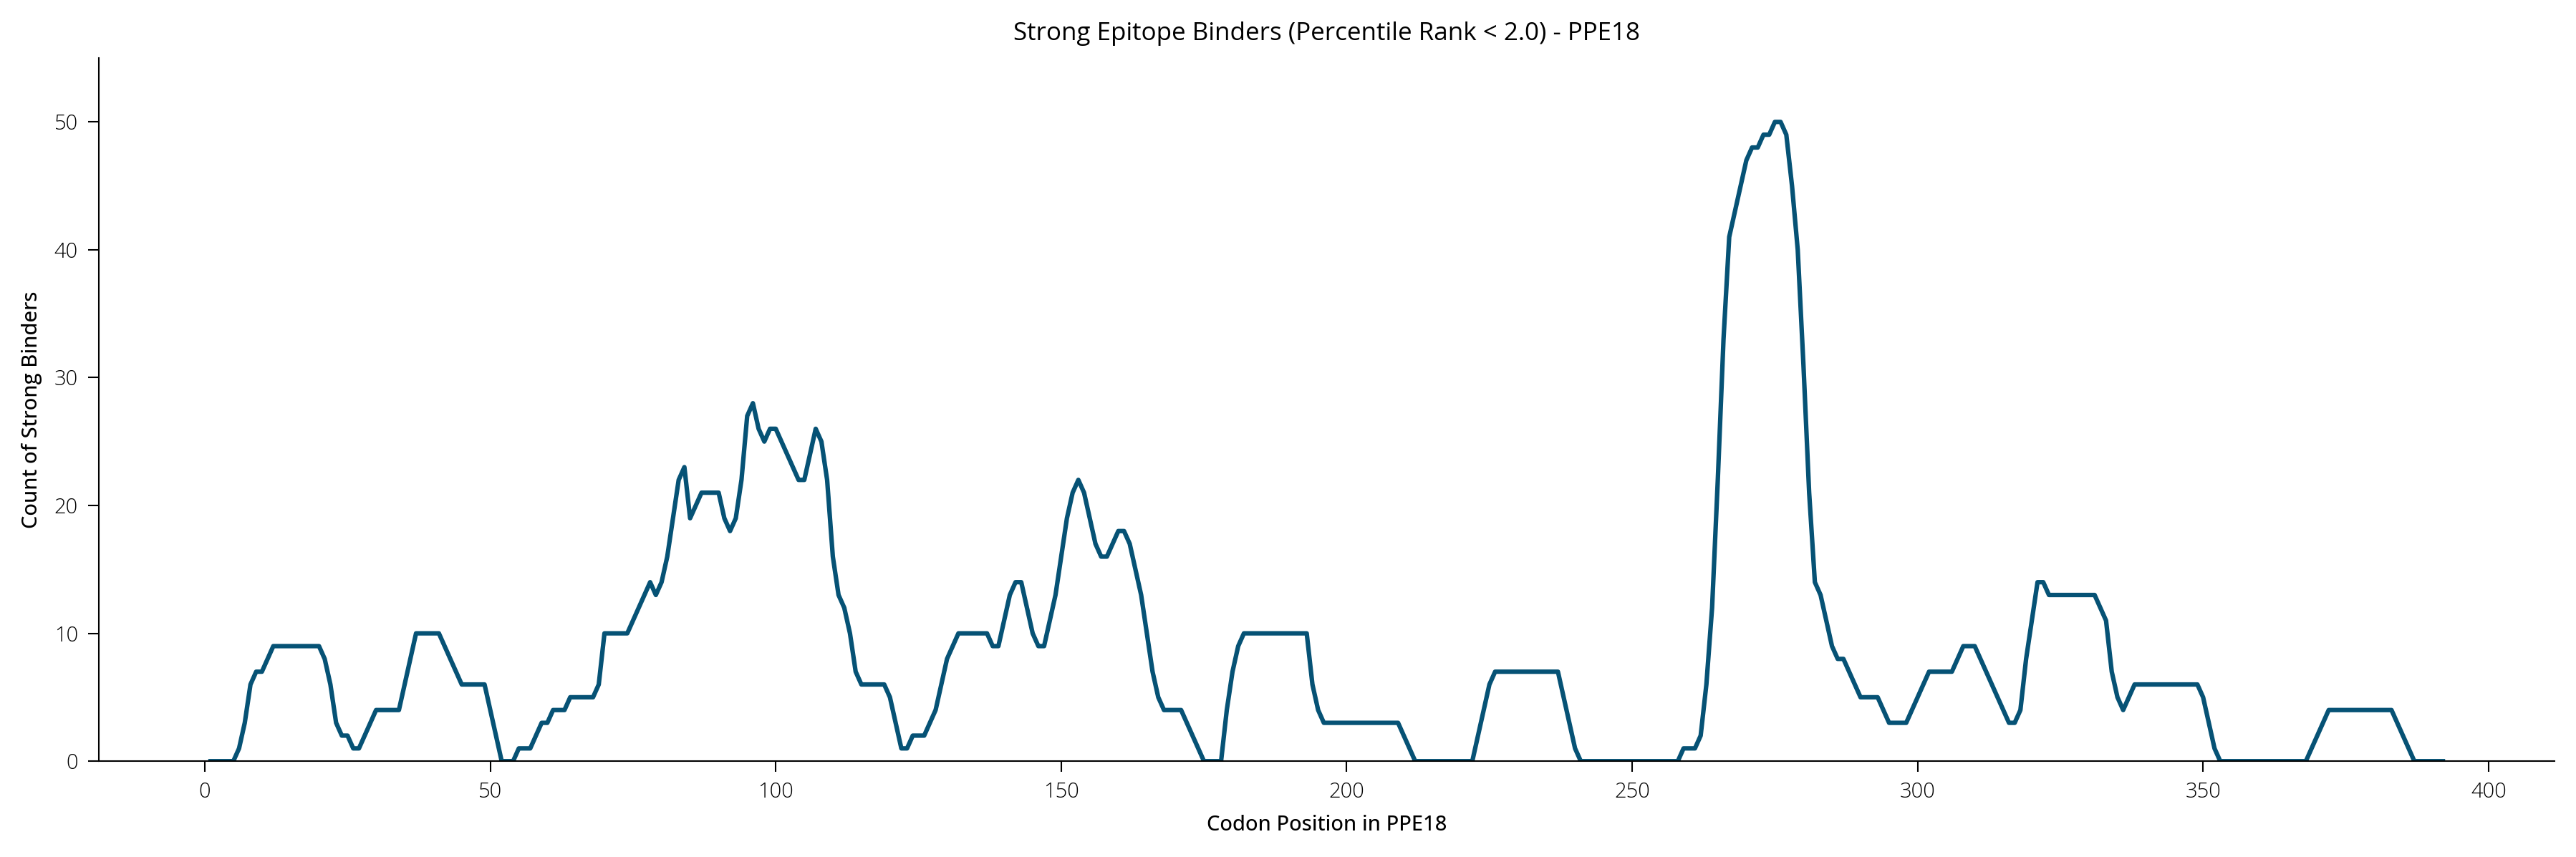

In [140]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=PPE18_netMHC_SB_Cov_DF,
             x="Codon", y="netMHCpan_Strong_Binder_Ct",
             linewidth=1.5)

plt.ylim(0, 55)

plt.title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
plt.xlabel("Codon Position in PPE18")
plt.ylabel("Count of Strong Binders")
plt.tight_layout()
sns.despine()
plt.show()

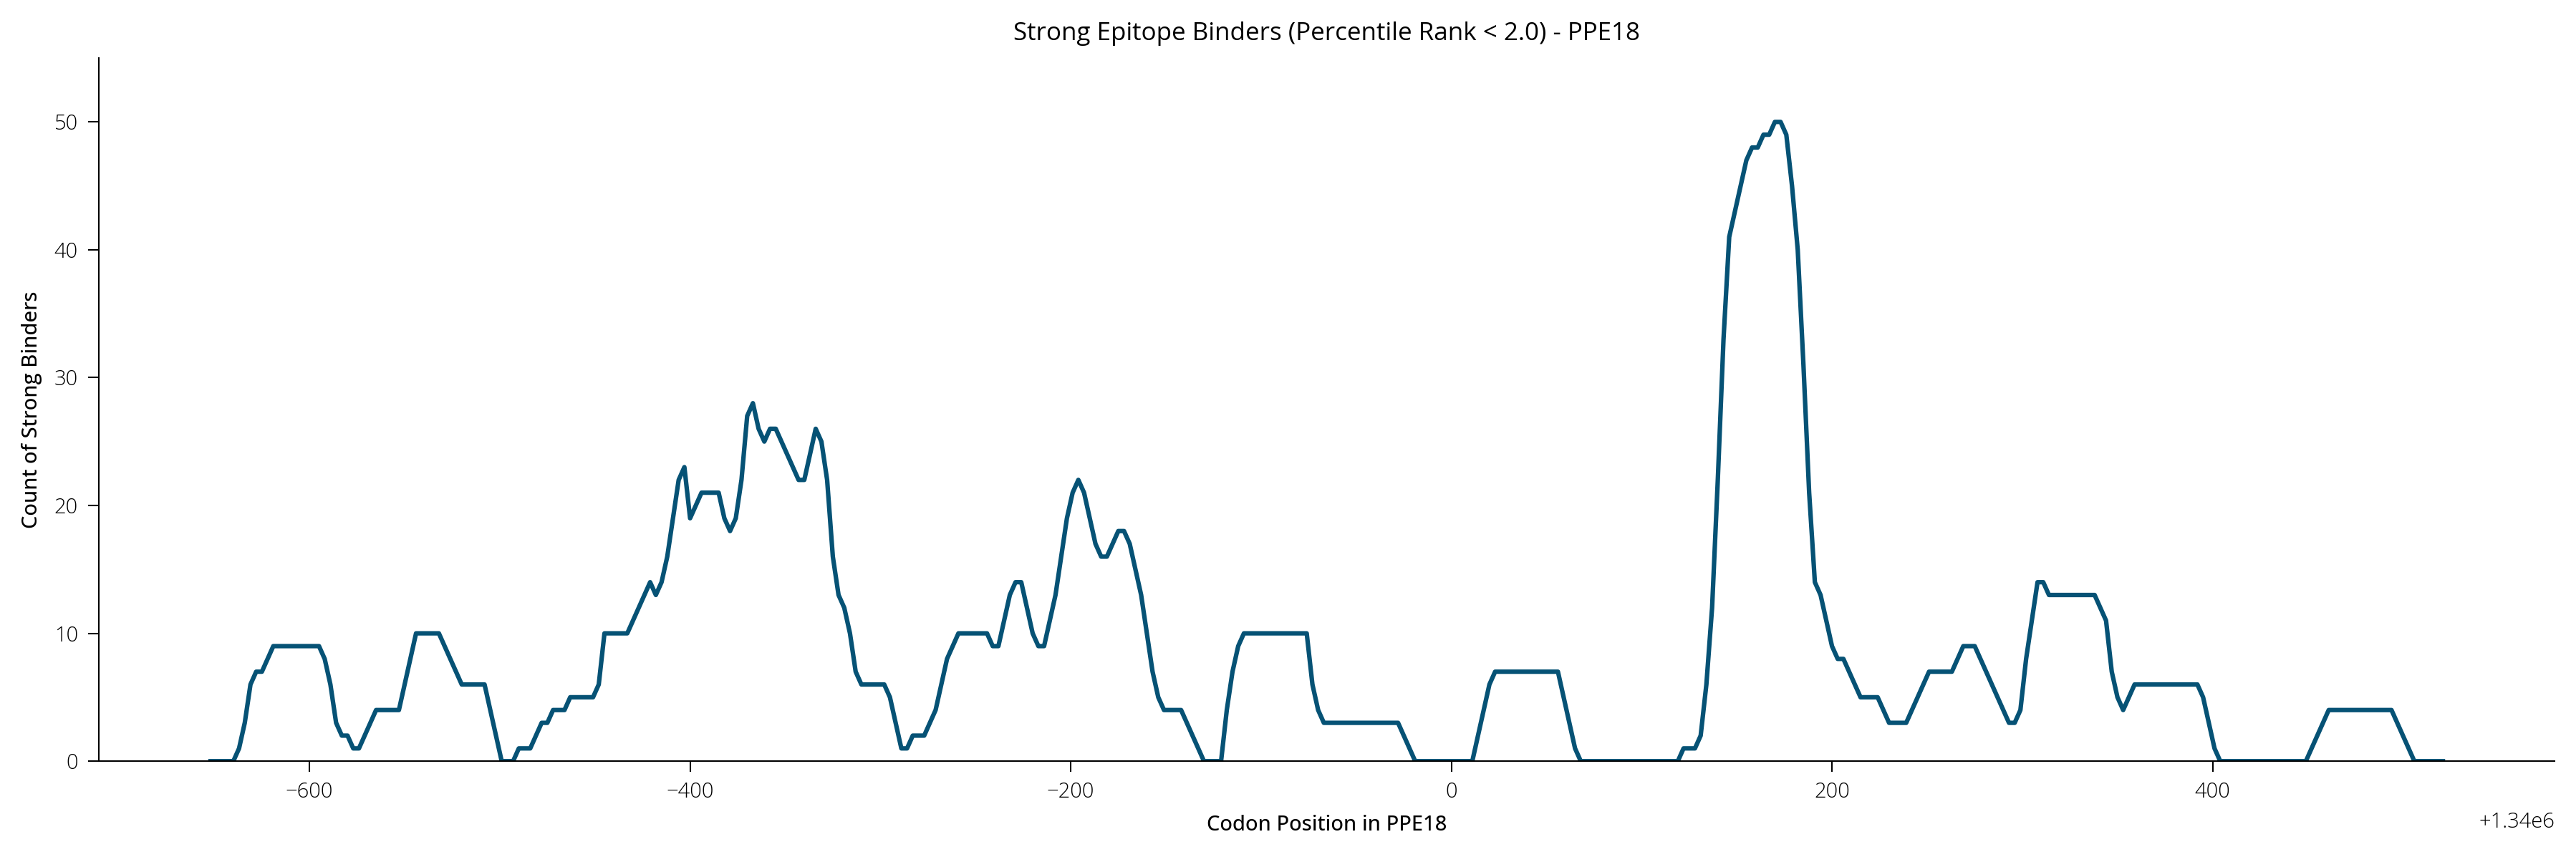

In [141]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=PPE18_netMHC_SB_Cov_DF,
             x = "Rv_Pos0",
             y = "netMHCpan_Strong_Binder_Ct",
             linewidth=1.5)
plt.ylim(0, 55)
plt.title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
plt.xlabel("Codon Position in PPE18")
plt.ylabel("Count of Strong Binders")
plt.tight_layout()
sns.despine()
plt.show()

### Explore predicted strong binder HLA Alleles 

In [142]:
PPE18_netMHCII_StrongBinders_DF.head(4)

,allele,seq_num,start,end,length,core_peptide,peptide,score,rank,Rv_Start,Rv_End,peptideID
0,HLA-DQA1*01:02/DQB1*06:02,1,84,98,15,LTAAQVRVA,AELTAAQVRVAAAAY,0.8876,0.01,1339597,1339639,PPE18_84-98
1,HLA-DQA1*01:02/DQB1*06:02,1,81,95,15,LTAAQVRVA,AGQAELTAAQVRVAA,0.8990,0.01,1339588,1339630,PPE18_81-95
2,HLA-DQA1*01:02/DQB1*06:02,1,82,96,15,LTAAQVRVA,GQAELTAAQVRVAAA,0.9304,0.01,1339591,1339633,PPE18_82-96
3,HLA-DQA1*01:02/DQB1*06:02,1,83,97,15,LTAAQVRVA,QAELTAAQVRVAAAA,0.9391,0.01,1339594,1339636,PPE18_83-97


In [143]:
len("AELTAAQVRVAAAAY")

15

### Create DNA-Features-Viewer objects for predicted `StrongBinder` epitopes within `PPE18`

In [147]:
netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_StrongBinders_DF.head(100))

#netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_StrongBinders_DF.query("Rv_Start == 1339597"))


#netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures = generate_netMHCpanII_Epitope_GraphicFeatures(PPE18_netMHCII_Pred_DF)


                                                 
netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                              features = netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures)


In [148]:
len(netMHCpanII_PPE18_StrongBindEpitopes_GraphicFeatures)

100

## Try to plot w/ PPE18 and Predicted Epitopes, etc

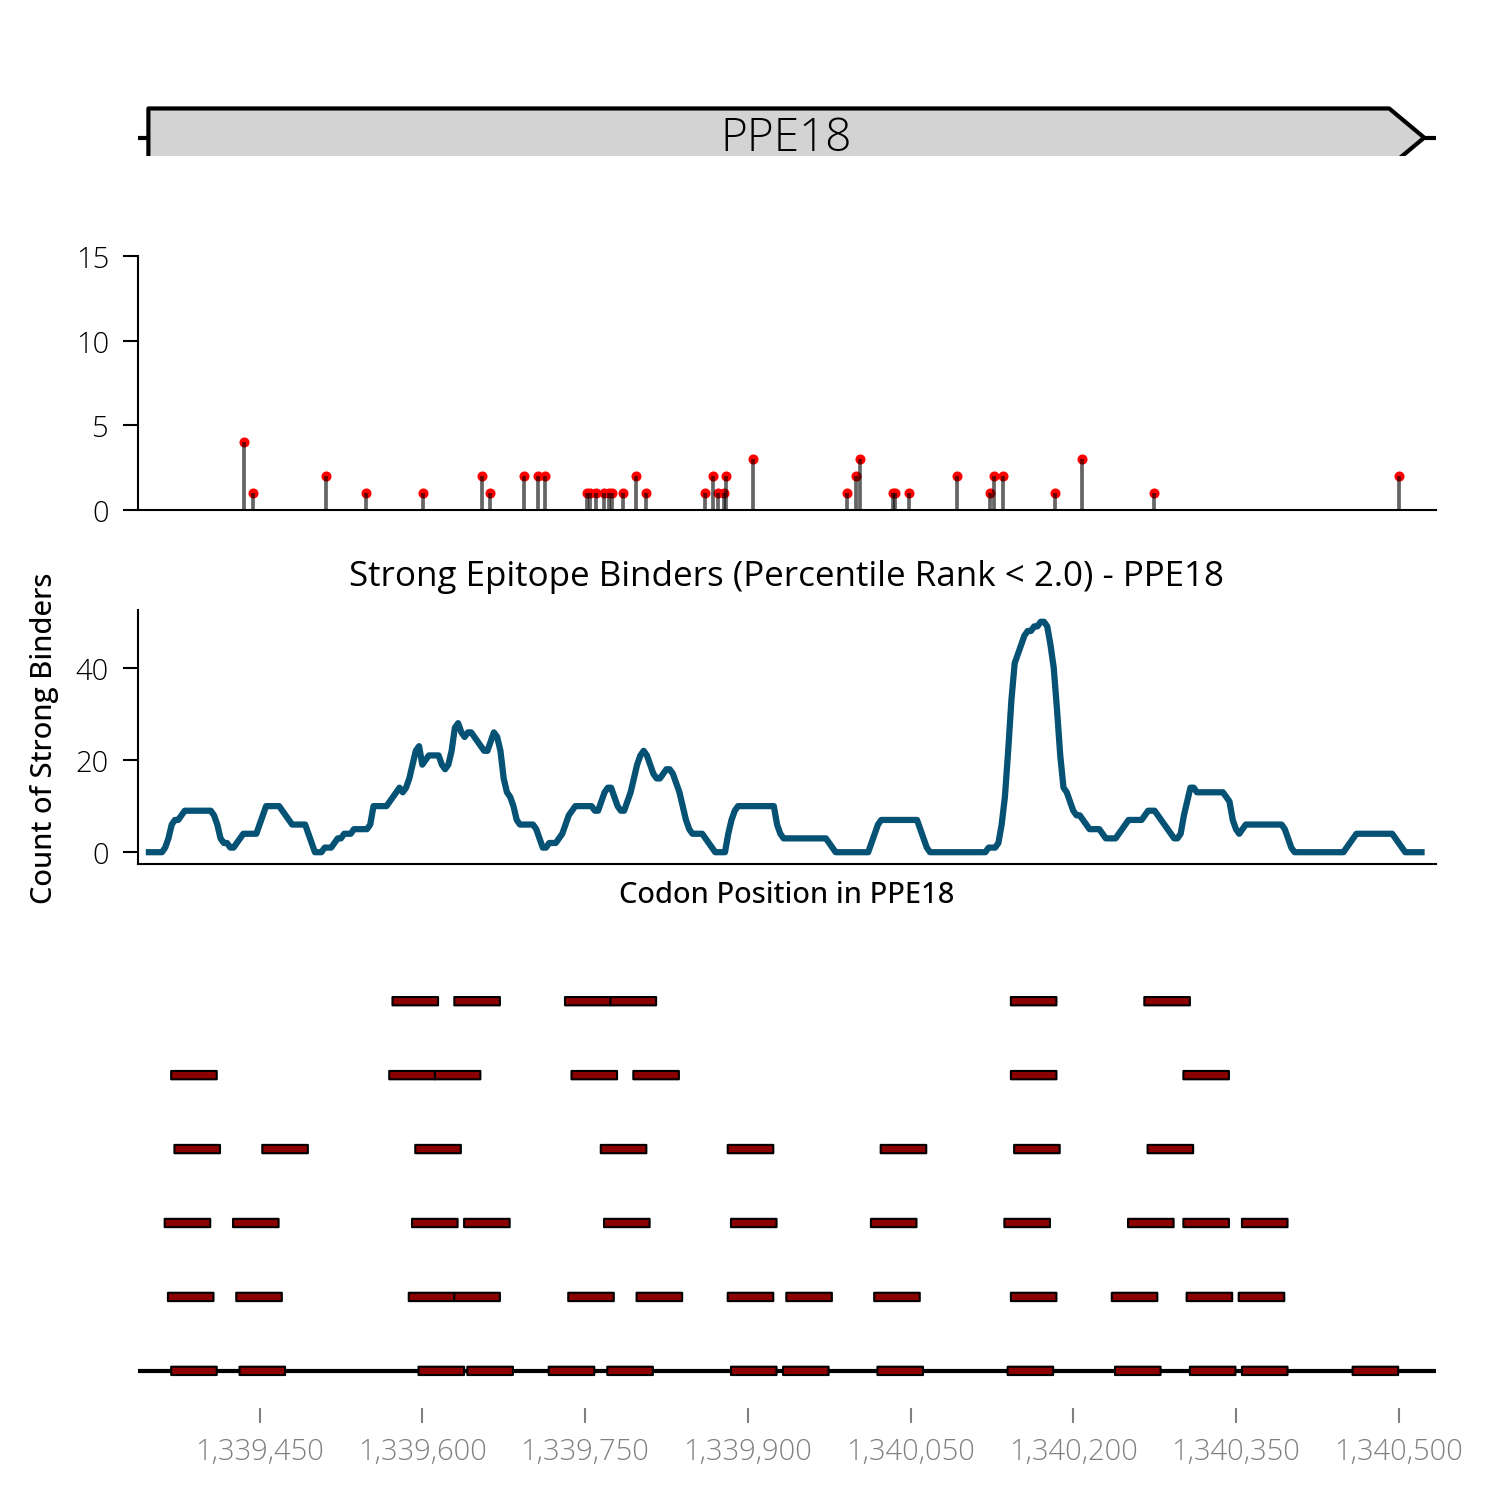

In [149]:

in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF

    

i_Symbol = "PPE18"
    
i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10



fig, axs = plt.subplots(4, 1, figsize=(5, 5),
                        gridspec_kw={'height_ratios': [2, 4, 4, 7]})         


# # C) Create graphic records for viz
Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

PPE18_StrongBindPredEpitopes_Records_cropped = netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))


#PosEpitopes_Records_cropped = LPM_PosEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))

### Define subplot location for different plots ###

# 1st subplot is of genome annotated features
H37Rv_Anno_ax = axs[0]

# 2nd subplot is for summary of epitope coverage per position
EpiSumm_ax = axs[2]

# 2nd subplot is for summary of epitope coverage per position

MF_ax = axs[1]

AllAssayedPeptides_ax = axs[3]


####### Gene Annotation Records #######
Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                            ax = H37Rv_Anno_ax)

H37Rv_Anno_ax.set_xlim(Viz_Start, Viz_End)

H37Rv_Anno_ax.set_xticks([])

#######################################


############## Mut Freq Plot ##############
MF_ax.vlines(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              ymin = 0, 
              ymax = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color = "black", linewidth=0.9, alpha = 0.6)

MF_ax.scatter(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              y = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color="red", s = 2, alpha = 1)

MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
MF_ax.ticklabel_format(style='plain', axis='x')
MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
MF_ax.set_xlim(Viz_Start, Viz_End)
MF_ax.set_ylim(0, 15)
MF_ax.set_xticks([])

sns.despine(ax=MF_ax)



###########################################

################# Predicted Epitope (StrongBinder) Coverage #################


sns.lineplot(data = PPE18_netMHC_SB_Cov_DF,
             x = "Rv_Pos0",
             y = "netMHCpan_Strong_Binder_Ct",
             linewidth=1.5,
             ax = EpiSumm_ax)

EpiSumm_ax.set_title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
EpiSumm_ax.set_xlabel("Codon Position in PPE18")
EpiSumm_ax.set_ylabel("Count of Strong Binders")
EpiSumm_ax.set_xlim(Viz_Start, Viz_End)

EpiSumm_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
EpiSumm_ax.ticklabel_format(style='plain', axis='x')
EpiSumm_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#MF_ax.set_ylim(0, 15)
EpiSumm_ax.set_xticks([])

sns.despine(ax=EpiSumm_ax)

#EpiSumm_ax.set_ylim(0, 1)


#####################################################


####### Predicted Epitopes - netMHCpanII #######
PredictedEpitopes_ax = axs[3]

PPE18_StrongBindPredEpitopes_Records_cropped.plot(strand_in_label_threshold=5,
                                 ax = PredictedEpitopes_ax)

PredictedEpitopes_ax.set_xlim(Viz_Start, Viz_End)
PredictedEpitopes_ax.set_ylim(-0.5, 5.5)

#AllAssayedPeptides_ax.set_xticks([])

######################################################

#plt.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")

plt.show()

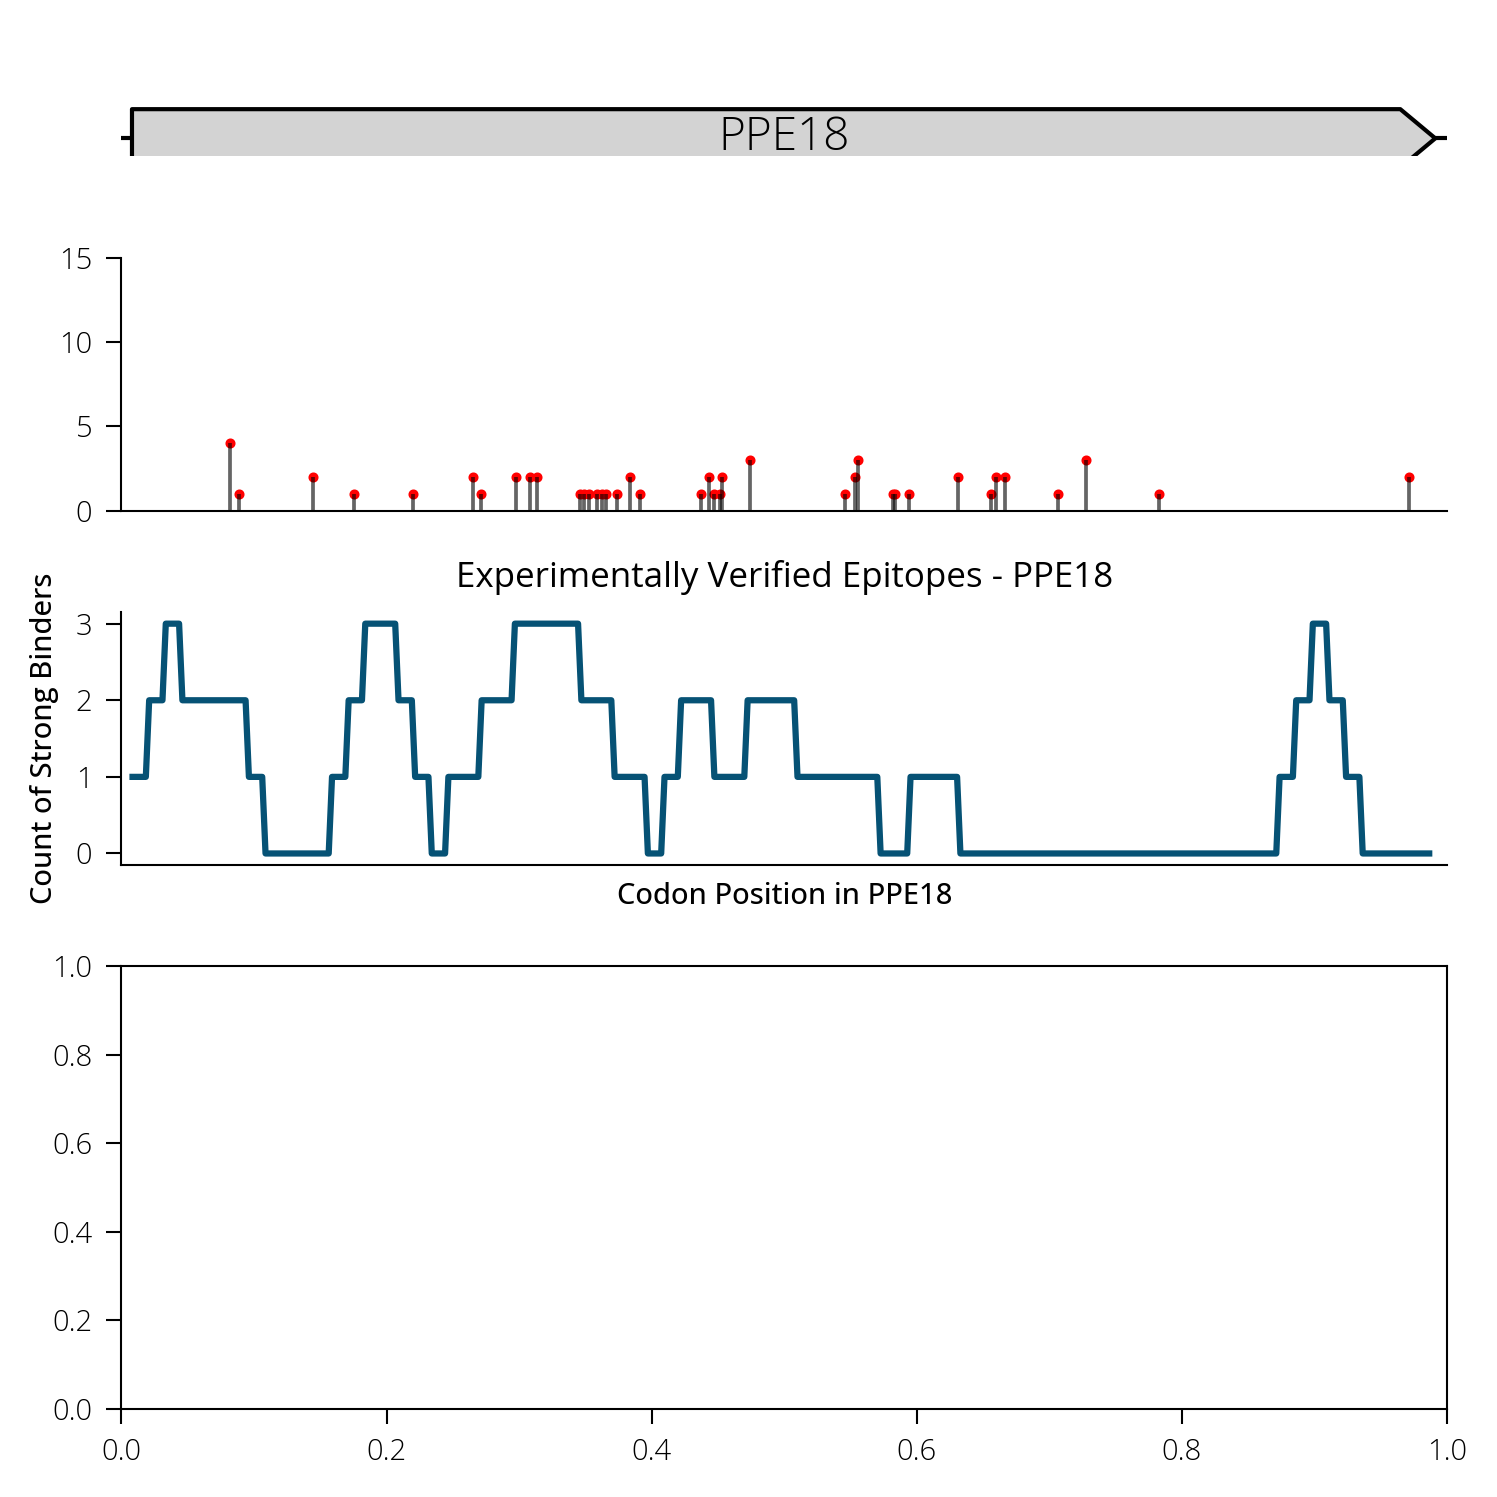

In [185]:

in_PerCodon_MutCt_DF = RvPerCodon_NSMutFreq_DF

in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record

in_AllPeptides_GraphicRecord = LPM_AllPeptides_GraphicRecord

in_EpitopeCov_DF = Rv_EpitopeCov_NonZero_DF

    

i_Symbol = "PPE18"
    
i_Gene_MutInfo_DF = Genes_GCandMutFreqStats_DF.query(f"Symbol == '{i_Symbol}'")

i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10



fig, axs = plt.subplots(4, 1, figsize=(5, 5),
                        gridspec_kw={'height_ratios': [2, 4, 4, 7]})         


# # C) Create graphic records for viz
Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))
AllPeptides_Records_cropped = in_AllPeptides_GraphicRecord.crop((Viz_Start, Viz_End + 1))

PPE18_StrongBindPredEpitopes_Records_cropped = netMHCpanII_PPE18_StrongBindEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))


#PosEpitopes_Records_cropped = LPM_PosEpitopes_GraphicRecord.crop((Viz_Start, Viz_End + 1))

### Define subplot location for different plots ###

# 1st subplot is of genome annotated features
H37Rv_Anno_ax = axs[0]

# 2nd subplot is for summary of epitope coverage per position
EpiSumm_ax = axs[2]

# 2nd subplot is for summary of epitope coverage per position

MF_ax = axs[1]

AllAssayedPeptides_ax = axs[3]


####### Gene Annotation Records #######
Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                            ax = H37Rv_Anno_ax)

H37Rv_Anno_ax.set_xlim(Viz_Start, Viz_End)

H37Rv_Anno_ax.set_xticks([])

#######################################


############## Mut Freq Plot ##############
MF_ax.vlines(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              ymin = 0, 
              ymax = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color = "black", linewidth=0.9, alpha = 0.6)

MF_ax.scatter(x = in_PerCodon_MutCt_DF["Pos_0based"].values + 1,
              y = in_PerCodon_MutCt_DF["Mutation_Count"].values,
              color="red", s = 2, alpha = 1)

MF_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
MF_ax.ticklabel_format(style='plain', axis='x')
MF_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
MF_ax.set_xlim(Viz_Start, Viz_End)
MF_ax.set_ylim(0, 15)
MF_ax.set_xticks([])

sns.despine(ax=MF_ax)



###########################################

################# Predicted Epitope (StrongBinder) Coverage #################


sns.lineplot(data = PPE18_netMHC_SB_Cov_DF,
             x = "Rv_Pos0",
             y = "Cov_PosEpitopes",
             linewidth=1.5,
             ax = EpiSumm_ax)

EpiSumm_ax.set_title("Experimentally Verified Epitopes - PPE18")
EpiSumm_ax.set_xlabel("Codon Position in PPE18")
EpiSumm_ax.set_ylabel("Count of Strong Binders")
EpiSumm_ax.set_xlim(Viz_Start, Viz_End)

EpiSumm_ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
EpiSumm_ax.ticklabel_format(style='plain', axis='x')
EpiSumm_ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
#MF_ax.set_ylim(0, 15)
EpiSumm_ax.set_xticks([])

sns.despine(ax=EpiSumm_ax)

#EpiSumm_ax.set_ylim(0, 1)


#####################################################


####### Predicted Epitopes - netMHCpanII #######
# PredictedEpitopes_ax = axs[3]

# PPE18_StrongBindPredEpitopes_Records_cropped.plot(strand_in_label_threshold=5,
#                                  ax = PredictedEpitopes_ax)

# PredictedEpitopes_ax.set_xlim(Viz_Start, Viz_End)
# PredictedEpitopes_ax.set_ylim(-0.5, 5.5)

#AllAssayedPeptides_ax.set_xticks([])

######################################################

#plt.savefig(f"GeneViz_EpitopeAndNSMutFreq_Plots/{i_Symbol}.EpitopeAndNSMutFreq.V2.svg")

plt.show()

# Part X

### 2) How many pGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (42/324, 13%)

In [186]:
pGCE_InAntigen_DF = pGCE_DF.query("(Overlap_WiAntigenLVL2Gene == True) ")
pGCE_InAntigen_DF.shape

(48, 46)

In [189]:
pGCE_InAntigen_DF[ pGCE_InAntigen_DF["Overlap_Genes"].str.contains("PPE18")]

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,Lineage,CenterOfRegion,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,EventLen,IsTermNode,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Freq_SNP_FoundInAnyPR,MaxJC_ToAnyRvGene,GeneIDs_MaxJC,NGenesIDs_MaxJC,NUnqHashes_Event,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,GUBBINS,CDS,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,lineage4,1339417.0,PPE18,Rv1196,False,True,False,False,Event_091,38,False,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,0.75,0.5769,"['PPE60', 'PPE19']",2.0,26.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,GUBBINS,CDS,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,lineage2,1339473.5,PPE18,Rv1196,False,True,False,False,Event_092,85,True,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,1.00,1.0000,['PPE19'],1.0,31.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,GUBBINS,CDS,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,lineage4,1339602.5,PPE18,Rv1196,False,True,False,False,Event_093,343,False,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,1.00,0.7027,"['PPE60', 'PPE19']",2.0,37.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,GUBBINS,CDS,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,lineage4,1339726.5,PPE18,Rv1196,False,True,False,False,Event_094,159,True,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856491.0,1.00,1.0000,['PPE60'],1.0,114.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."
94,NC_000962.3,GUBBINS,CDS,1339861,1339905,0.0,.,Node_43,TB3237,688.268204,12,['TB3237'],1339860,lineage4,1339882.5,PPE18,Rv1196,False,True,False,False,Event_095,45,True,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",1.0000,NaN,55,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856647.0,1.00,1.0000,"['PPE60', 'PPE19']",2.0,55.0,True,8,4,3,"UnqPeptide_998-PPE18,UnqPeptide_8744-PPE18,Unq..."
95,NC_000962.3,GUBBINS,CDS,1339894,1340208,0.0,.,Node_17,TB3334,993.431569,8,['TB3334'],1339893,lineage4,1340050.5,PPE18,Rv1196,False,True,False,False,Event_096,315,True,2,1,PPE19-H37Rv-1532539-1533632,PPE19,0.9688,193035.0,64,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856815.0,1.00,0.9688,['PPE19'],1.0,64.0,True,7,3,12,"UnqPeptide_959-PPE18,UnqPeptide_998-PPE18,UnqP..."
96,NC_000962.3,GUBBINS,CDS,1339966,1340036,0.0,.,Node_37,01_R1430,622.305357,11,['01_R1430'],1339965,lineage4,1340000.5,PPE18,Rv1196,False,True,False,False,Event_097,71,True,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856765.0,57,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856765.0,1.00,1.0000,['PPE60'],1.0,57.0,True,8,1,6,UnqPeptide_15452-PPE18
97,NC_000962.3,GUBBINS,CDS,1340500,1341152,0.0,.,Node_149,RW-TB008,4520.801917,10,['RW-TB008'],1340499,lineage8,1340825.5,"PPE18,esxK,esxL","Rv1196,Rv1197,Rv1198",True,True,False,False,Event_098,653,True,4,1,"esxI,esxJ-H37Rv-1160545-1161167","esxI,esxJ",0.1573,179969.5,89,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.30,689828.0,0.60,0.1236,['esxM'],1.0,89.0,True,3,1,4,Unq

In [187]:
pGCE_InAntigen_DF.head()

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,Lineage,CenterOfRegion,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,EventLen,IsTermNode,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Freq_SNP_FoundInAnyPR,MaxJC_ToAnyRvGene,GeneIDs_MaxJC,NGenesIDs_MaxJC,NUnqHashes_Event,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,GUBBINS,CDS,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,lineage4,1339417.0,PPE18,Rv1196,False,True,False,False,Event_091,38,False,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,0.75,0.5769,"['PPE60', 'PPE19']",2.0,26.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,GUBBINS,CDS,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,lineage2,1339473.5,PPE18,Rv1196,False,True,False,False,Event_092,85,True,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,1.00,1.0000,['PPE19'],1.0,31.0,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,GUBBINS,CDS,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,lineage4,1339602.5,PPE18,Rv1196,False,True,False,False,Event_093,343,False,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,1.00,0.7027,"['PPE60', 'PPE19']",2.0,37.0,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,GUBBINS,CDS,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,lineage4,1339726.5,PPE18,Rv1196,False,True,False,False,Event_094,159,True,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856491.0,1.00,1.0000,['PPE60'],1.0,114.0,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."
94,NC_000962.3,GUBBINS,CDS,1339861,1339905,0.0,.,Node_43,TB3237,688.268204,12,['TB3237'],1339860,lineage4,1339882.5,PPE18,Rv1196,False,True,False,False,Event_095,45,True,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",1.0000,NaN,55,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856647.0,1.00,1.0000,"['PPE60', 'PPE19']",2.0,55.0,True,8,4,3,"UnqPeptide_998-PPE18,UnqPeptide_8744-PPE18,Unq..."


# Extras